# Building Stock Indices

Note: __yfinance can be unstable/unreliable from time to time__ when it comes to downloading fundamental data with the ticker object. In particular, __ticker.get_info()__ can be flawed.

__Action required__: Check for the __latest yfinance versions__ and update with the following command (Anaconda Prompt / Terminal):

pip install yfinance --upgrade

In the following, I have added an __alternative Yahoo Finance API Wrapper__, __yahooquery__

__Action required: Please install yahooquery with the following command (Anaconda Prompt / Terminal):__

pip install yahooquery --upgrade

Note: 
- Please make sure you have installed the __latest__ yahooquery version (if not, please upgrade). 

__Update December 2023__: Sometimes yfinance is more stable/reliable and sometimes yahooquery is more stable/reliable. Most recently, yfinance seemed to be better. In any case, __please make sure you have the latest versions installed!__

In [2]:
#%pip install --upgrade yfinance

## Getting started

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
pd.set_option('display.float_format', lambda x: '%.5f' % x)
plt.style.use("ggplot")

import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%config InlineBackend.figure_format = 'retina'

In [143]:
df = pd.read_csv("DJI_Const.csv", header = [0, 1], index_col = 0, parse_dates=[0])
df

Adj Close                                                    \
                AAPL      AMGN       AXP        BA       CAT       CRM   
Date                                                                     
2020-08-31 127.28973 238.21722  98.72124 171.82001 135.36957 272.64999   
2020-09-01 132.36002 235.90388  99.57639 172.10001 138.92717 281.25000   
2020-09-02 129.61771 242.73103 101.45189 174.78000 141.99014 276.69000   
2020-09-03 119.24042 233.12975 101.51020 168.77000 139.60254 265.01001   
2020-09-04 119.31931 233.59055 102.68602 171.05000 140.95329 254.70000   
...              ...       ...       ...       ...       ...       ...   
2022-11-09 134.87000 289.64999 145.86000 168.74001 225.53999 142.06000   
2022-11-10 146.87000 291.01001 154.75000 177.58000 232.45000 156.30000   
2022-11-11 149.70000 285.01999 154.89000 177.49001 236.49001 157.73000   
2022-11-14 148.28000 285.29999 154.13000 173.55000 236.50000 158.66000   
2022-11-15 150.03999 283.60001 153.89000 175.35001 234.59000 162.07001   

                                                  ...    Volume            \
               CSCO       CVX       DIS      DOW  ...      MSFT       NKE   
Date                                              ...                       
2020-08-31 39.40549  76.44771 131.87000 41.14776  ...  28774200   3519800   
2020-09-01 39.22816  75.67349 133.55000 43.10848  ...  25725500   4912400   
2020-09-02 39.59216  75.77369 135.39000 44.88681  ...  34080800   6775400   
2020-09-03 38.22016  74.94482 133.24001 44.12988  ...  58400300   7264400   
2020-09-04 38.09882  74.62601 131.99001 44.32140  ...  59664100   5157600   
...             ...       ...       ...      ...  ...       ...       ...   
2022-11-09 43.91000 177.92999  86.75000 47.68000  ...  27852900   6550900   
2022-11-10 45.66000 181.30000  90.46000 49.96000  ...  46268000   9361000   
2022-11-11 44.79000 186.46001  95.01000 53.14000  ...  34600900  12595600   
2022-11-14 44.74000 186.55000  94.28000 51.95000  ...  31123300   7134900   
2022-11-15 44.90000 188.05000  95.51000 51.60000  ...  31367300   7241000   

                                                                               \
                 PG      TRV      UNH         V        VZ       WBA       WMT   
Date                                                                            
2020-08-31  5596800  2297900  4341600   9326900  14555500   7940100  15078800   
2020-09-01  5671800   969900  2487100   5642900  13358400  10728300  35599400   
2020-09-02  8384800  1391400  2846500   9863800  21711900   7672400  17222000   
2020-09-03  7277900  1299400  3872500  11310200  23126800   8278000  16005000   
2020-09-04  7437700  1460700  2901000  13243600  22250100   6994400  11327400   
...             ...      ...      ...       ...       ...       ...       ...   
2022-11-09  5690700   999200  2672600   7320200  17574600   6830500   5310700   
2022-11-10  8068700  1618000  3426400   8048900  23049000   8825000   6770200   
2022-11-11  7174400  1403300  7032900   9600700  22978900  13098600   6419700   
2022-11-14  8516200  1427300  5238400   5796100  23028500   8301900  12508600   
2022-11-15  7731700  1445900  5102800   7315700  25058900   6755300  25504700   

                       
                 ^DJI  
Date                   
2020-08-31  517320000  
2020-09-01  423410000  
2020-09-02  539510000  
2020-09-03  650080000  
2020-09-04  694640000  
...               ...  
2022-11-09  355200000  
2022-11-10  480130000  
2022-11-11  427790000  
2022-11-14  354340000  
2022-11-15  390610000  

[558 rows x 186 columns]

In [3]:
df.dropna(inplace = True)
df

Adj Close                                                    \
                AAPL      AMGN       AXP        BA       CAT       CRM   
Date                                                                     
2020-08-31 127.28973 238.21722  98.72124 171.82001 135.36957 272.64999   
2020-09-01 132.36002 235.90388  99.57639 172.10001 138.92717 281.25000   
2020-09-02 129.61771 242.73103 101.45189 174.78000 141.99014 276.69000   
2020-09-03 119.24042 233.12975 101.51020 168.77000 139.60254 265.01001   
2020-09-04 119.31931 233.59055 102.68602 171.05000 140.95329 254.70000   
...              ...       ...       ...       ...       ...       ...   
2022-11-09 134.87000 289.64999 145.86000 168.74001 225.53999 142.06000   
2022-11-10 146.87000 291.01001 154.75000 177.58000 232.45000 156.30000   
2022-11-11 149.70000 285.01999 154.89000 177.49001 236.49001 157.73000   
2022-11-14 148.28000 285.29999 154.13000 173.55000 236.50000 158.66000   
2022-11-15 150.03999 283.60001 153.89000 175.35001 234.59000 162.07001   

                                                  ...    Volume            \
               CSCO       CVX       DIS      DOW  ...      MSFT       NKE   
Date                                              ...                       
2020-08-31 39.40549  76.44771 131.87000 41.14776  ...  28774200   3519800   
2020-09-01 39.22816  75.67349 133.55000 43.10848  ...  25725500   4912400   
2020-09-02 39.59216  75.77369 135.39000 44.88681  ...  34080800   6775400   
2020-09-03 38.22016  74.94482 133.24001 44.12988  ...  58400300   7264400   
2020-09-04 38.09882  74.62601 131.99001 44.32140  ...  59664100   5157600   
...             ...       ...       ...      ...  ...       ...       ...   
2022-11-09 43.91000 177.92999  86.75000 47.68000  ...  27852900   6550900   
2022-11-10 45.66000 181.30000  90.46000 49.96000  ...  46268000   9361000   
2022-11-11 44.79000 186.46001  95.01000 53.14000  ...  34600900  12595600   
2022-11-14 44.74000 186.55000  94.28000 51.95000  ...  31123300   7134900   
2022-11-15 44.90000 188.05000  95.51000 51.60000  ...  31367300   7241000   

                                                                               \
                 PG      TRV      UNH         V        VZ       WBA       WMT   
Date                                                                            
2020-08-31  5596800  2297900  4341600   9326900  14555500   7940100  15078800   
2020-09-01  5671800   969900  2487100   5642900  13358400  10728300  35599400   
2020-09-02  8384800  1391400  2846500   9863800  21711900   7672400  17222000   
2020-09-03  7277900  1299400  3872500  11310200  23126800   8278000  16005000   
2020-09-04  7437700  1460700  2901000  13243600  22250100   6994400  11327400   
...             ...      ...      ...       ...       ...       ...       ...   
2022-11-09  5690700   999200  2672600   7320200  17574600   6830500   5310700   
2022-11-10  8068700  1618000  3426400   8048900  23049000   8825000   6770200   
2022-11-11  7174400  1403300  7032900   9600700  22978900  13098600   6419700   
2022-11-14  8516200  1427300  5238400   5796100  23028500   8301900  12508600   
2022-11-15  7731700  1445900  5102800   7315700  25058900   6755300  25504700   

                       
                 ^DJI  
Date                   
2020-08-31  517320000  
2020-09-01  423410000  
2020-09-02  539510000  
2020-09-03  650080000  
2020-09-04  694640000  
...               ...  
2022-11-09  355200000  
2022-11-10  480130000  
2022-11-11  427790000  
2022-11-14  354340000  
2022-11-15  390610000  

[558 rows x 186 columns]

In [4]:
close = df.Close.copy()
close

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,129.03999,253.32001,101.59000,171.82001,142.31000,272.64999,42.22000,83.93000,131.87000,45.12000,...,225.53000,111.89000,138.33000,116.04000,312.54999,211.99001,59.27000,38.02000,138.85001,28430.05078
2020-09-01,134.17999,250.86000,102.47000,172.10001,146.05000,281.25000,42.03000,83.08000,133.55000,47.27000,...,227.27000,114.84000,138.17999,114.69000,312.82999,213.35001,59.16000,36.76000,147.59000,28645.66016
2020-09-02,131.39999,258.12000,104.40000,174.78000,149.27000,276.69000,42.42000,83.19000,135.39000,49.22000,...,231.64999,116.80000,140.50999,117.48000,320.23999,216.48000,60.53000,37.17000,147.67999,29100.50000
2020-09-03,120.88000,247.91000,104.46000,168.77000,146.75999,265.01001,40.95000,82.28000,133.24001,48.39000,...,217.30000,112.85000,138.25999,115.35000,316.23001,208.96001,60.61000,37.09000,144.53999,28292.73047
2020-09-04,120.96000,248.39999,105.67000,171.05000,148.17999,254.70000,40.82000,81.93000,131.99001,48.60000,...,214.25000,112.40000,137.96001,116.57000,312.00000,204.66000,60.48000,36.89000,142.83000,28133.31055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,134.87000,289.64999,145.86000,168.74001,225.53999,142.06000,43.91000,177.92999,86.75000,47.68000,...,224.50999,92.10000,136.48000,182.14999,540.65997,193.92999,37.62000,36.89000,139.47000,32513.93945
2022-11-10,146.87000,291.01001,154.75000,177.58000,232.45000,156.30000,45.66000,181.30000,90.46000,49.96000,...,242.98000,99.49000,141.17999,183.30000,544.16998,205.57001,38.52000,38.49000,142.36000,33715.37109
2022-11-11,149.70000,285.01999,154.89000,177.49001,236.49001,157.73000,44.79000,186.46001,95.01000,53.14000,...,247.11000,106.09000,140.97000,181.73000,522.08002,205.00000,38.30000,41.26000,142.58000,33747.85938


In [5]:
returns = close.pct_change() # simple returns
returns

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,0.03983,-0.00971,0.00866,0.00163,0.02628,0.03154,-0.00450,-0.01013,0.01274,0.04765,...,0.00772,0.02637,-0.00108,-0.01163,0.00090,0.00642,-0.00186,-0.03314,0.06295,0.00758
2020-09-02,-0.02072,0.02894,0.01883,0.01557,0.02205,-0.01621,0.00928,0.00132,0.01378,0.04125,...,0.01927,0.01707,0.01686,0.02433,0.02369,0.01467,0.02316,0.01115,0.00061,0.01588
2020-09-03,-0.08006,-0.03956,0.00057,-0.03439,-0.01682,-0.04221,-0.03465,-0.01094,-0.01588,-0.01686,...,-0.06195,-0.03382,-0.01601,-0.01813,-0.01252,-0.03474,0.00132,-0.00215,-0.02126,-0.02776
2020-09-04,0.00066,0.00198,0.01158,0.01351,0.00968,-0.03890,-0.00317,-0.00425,-0.00938,0.00434,...,-0.01404,-0.00399,-0.00217,0.01058,-0.01338,-0.02058,-0.00214,-0.00539,-0.01183,-0.00563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.03319,-0.00937,-0.02889,-0.00519,-0.01858,-0.03426,-0.01569,-0.03998,-0.13163,-0.03968,...,-0.01905,-0.01760,-0.00241,-0.01487,-0.02240,-0.03890,-0.00660,-0.03656,-0.02325,-0.01951
2022-11-10,0.08897,0.00470,0.06095,0.05239,0.03064,0.10024,0.03985,0.01894,0.04277,0.04782,...,0.08227,0.08024,0.03444,0.00631,0.00649,0.06002,0.02392,0.04337,0.02072,0.03695
2022-11-11,0.01927,-0.02058,0.00090,-0.00051,0.01738,0.00915,-0.01905,0.02846,0.05030,0.06365,...,0.01700,0.06634,-0.00149,-0.00857,-0.04059,-0.00277,-0.00571,0.07197,0.00155,0.00096


In [6]:
index = "^DJI"

In [7]:
const = close.columns.drop([index])
const

Index(['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'DOW',
       'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM',
       'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WBA', 'WMT'],
      dtype='object')

## Building a Price-weighted Index

In [8]:
close[const]

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,129.03999,253.32001,101.59000,171.82001,142.31000,272.64999,42.22000,83.93000,131.87000,45.12000,...,81.36450,225.53000,111.89000,138.33000,116.04000,312.54999,211.99001,59.27000,38.02000,138.85001
2020-09-01,134.17999,250.86000,102.47000,172.10001,146.05000,281.25000,42.03000,83.08000,133.55000,47.27000,...,80.56298,227.27000,114.84000,138.17999,114.69000,312.82999,213.35001,59.16000,36.76000,147.59000
2020-09-02,131.39999,258.12000,104.40000,174.78000,149.27000,276.69000,42.42000,83.19000,135.39000,49.22000,...,82.94847,231.64999,116.80000,140.50999,117.48000,320.23999,216.48000,60.53000,37.17000,147.67999
2020-09-03,120.88000,247.91000,104.46000,168.77000,146.75999,265.01001,40.95000,82.28000,133.24001,48.39000,...,81.57442,217.30000,112.85000,138.25999,115.35000,316.23001,208.96001,60.61000,37.09000,144.53999
2020-09-04,120.96000,248.39999,105.67000,171.05000,148.17999,254.70000,40.82000,81.93000,131.99001,48.60000,...,81.33588,214.25000,112.40000,137.96001,116.57000,312.00000,204.66000,60.48000,36.89000,142.83000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,134.87000,289.64999,145.86000,168.74001,225.53999,142.06000,43.91000,177.92999,86.75000,47.68000,...,101.59000,224.50999,92.10000,136.48000,182.14999,540.65997,193.92999,37.62000,36.89000,139.47000
2022-11-10,146.87000,291.01001,154.75000,177.58000,232.45000,156.30000,45.66000,181.30000,90.46000,49.96000,...,101.89000,242.98000,99.49000,141.17999,183.30000,544.16998,205.57001,38.52000,38.49000,142.36000
2022-11-11,149.70000,285.01999,154.89000,177.49001,236.49001,157.73000,44.79000,186.46001,95.01000,53.14000,...,97.96000,247.11000,106.09000,140.97000,181.73000,522.08002,205.00000,38.30000,41.26000,142.58000


In [9]:
close[const].sum(axis = 0)

AAPL    80260.59000
AMGN   131750.19026
AXP     84627.04990
BA     108546.64010
CAT    111715.41029
CRM    123465.30983
CSCO    27626.16998
CVX     67547.91001
DIS     82214.71996
DOW     32206.48003
GS     183077.24005
HD     173837.10985
HON    112858.46994
IBM     71494.98804
INTC    27117.90997
JNJ     92215.82002
JPM     76563.15988
KO      31561.72998
MCD    133135.27003
MMM     92822.93991
MRK     44971.79396
MSFT   147804.79985
NKE     74905.19014
PG      79347.80000
TRV     86679.71997
UNH    241512.84030
V      119003.22005
VZ      29517.96999
WBA     25072.26999
WMT     78187.70007
dtype: float64

In [63]:
close[const].sum(axis = 1)

Date
2020-08-31   4311.67171
2020-09-01   4344.47622
2020-09-02   4413.28146
2020-09-03   4290.74151
2020-09-04   4266.61749
                ...    
2022-11-09   4933.25994
2022-11-10   5115.55000
2022-11-11   5120.48003
2022-11-14   5088.43999
2022-11-15   5096.97002
Length: 558, dtype: float64

In [10]:
close[const].sum(axis = 1).iloc[0] # sum of prices day 1

np.float64(4311.67170715332)

__Index (Base Value = 100)__

In [12]:
pwi = close[const].sum(axis = 1).div(close[const].sum(axis = 1).iloc[0]).mul(100)
pwi

Date
2020-08-31   100.00000
2020-09-01   100.76083
2020-09-02   102.35662
2020-09-03    99.51457
2020-09-04    98.95506
                ...   
2022-11-09   114.41641
2022-11-10   118.64424
2022-11-11   118.75858
2022-11-14   118.01548
2022-11-15   118.21331
Length: 558, dtype: float64

In [13]:
pwi.name = "pwi" # PWI: Price Weighted Index
pwi

Date
2020-08-31   100.00000
2020-09-01   100.76083
2020-09-02   102.35662
2020-09-03    99.51457
2020-09-04    98.95506
                ...   
2022-11-09   114.41641
2022-11-10   118.64424
2022-11-11   118.75858
2022-11-14   118.01548
2022-11-15   118.21331
Name: pwi, Length: 558, dtype: float64

__Cross-Check with DJI Data__

In [15]:
dji_first_day = close["^DJI"].iloc[0]
dji_norm = close["^DJI"].div(dji_first_day).mul(100)
dji_norm

Date
2020-08-31   100.00000
2020-09-01   100.75839
2020-09-02   102.35824
2020-09-03    99.51699
2020-09-04    98.95624
                ...   
2022-11-09   114.36469
2022-11-10   118.59061
2022-11-11   118.70489
2022-11-14   117.96215
2022-11-15   118.15991
Name: ^DJI, Length: 558, dtype: float64

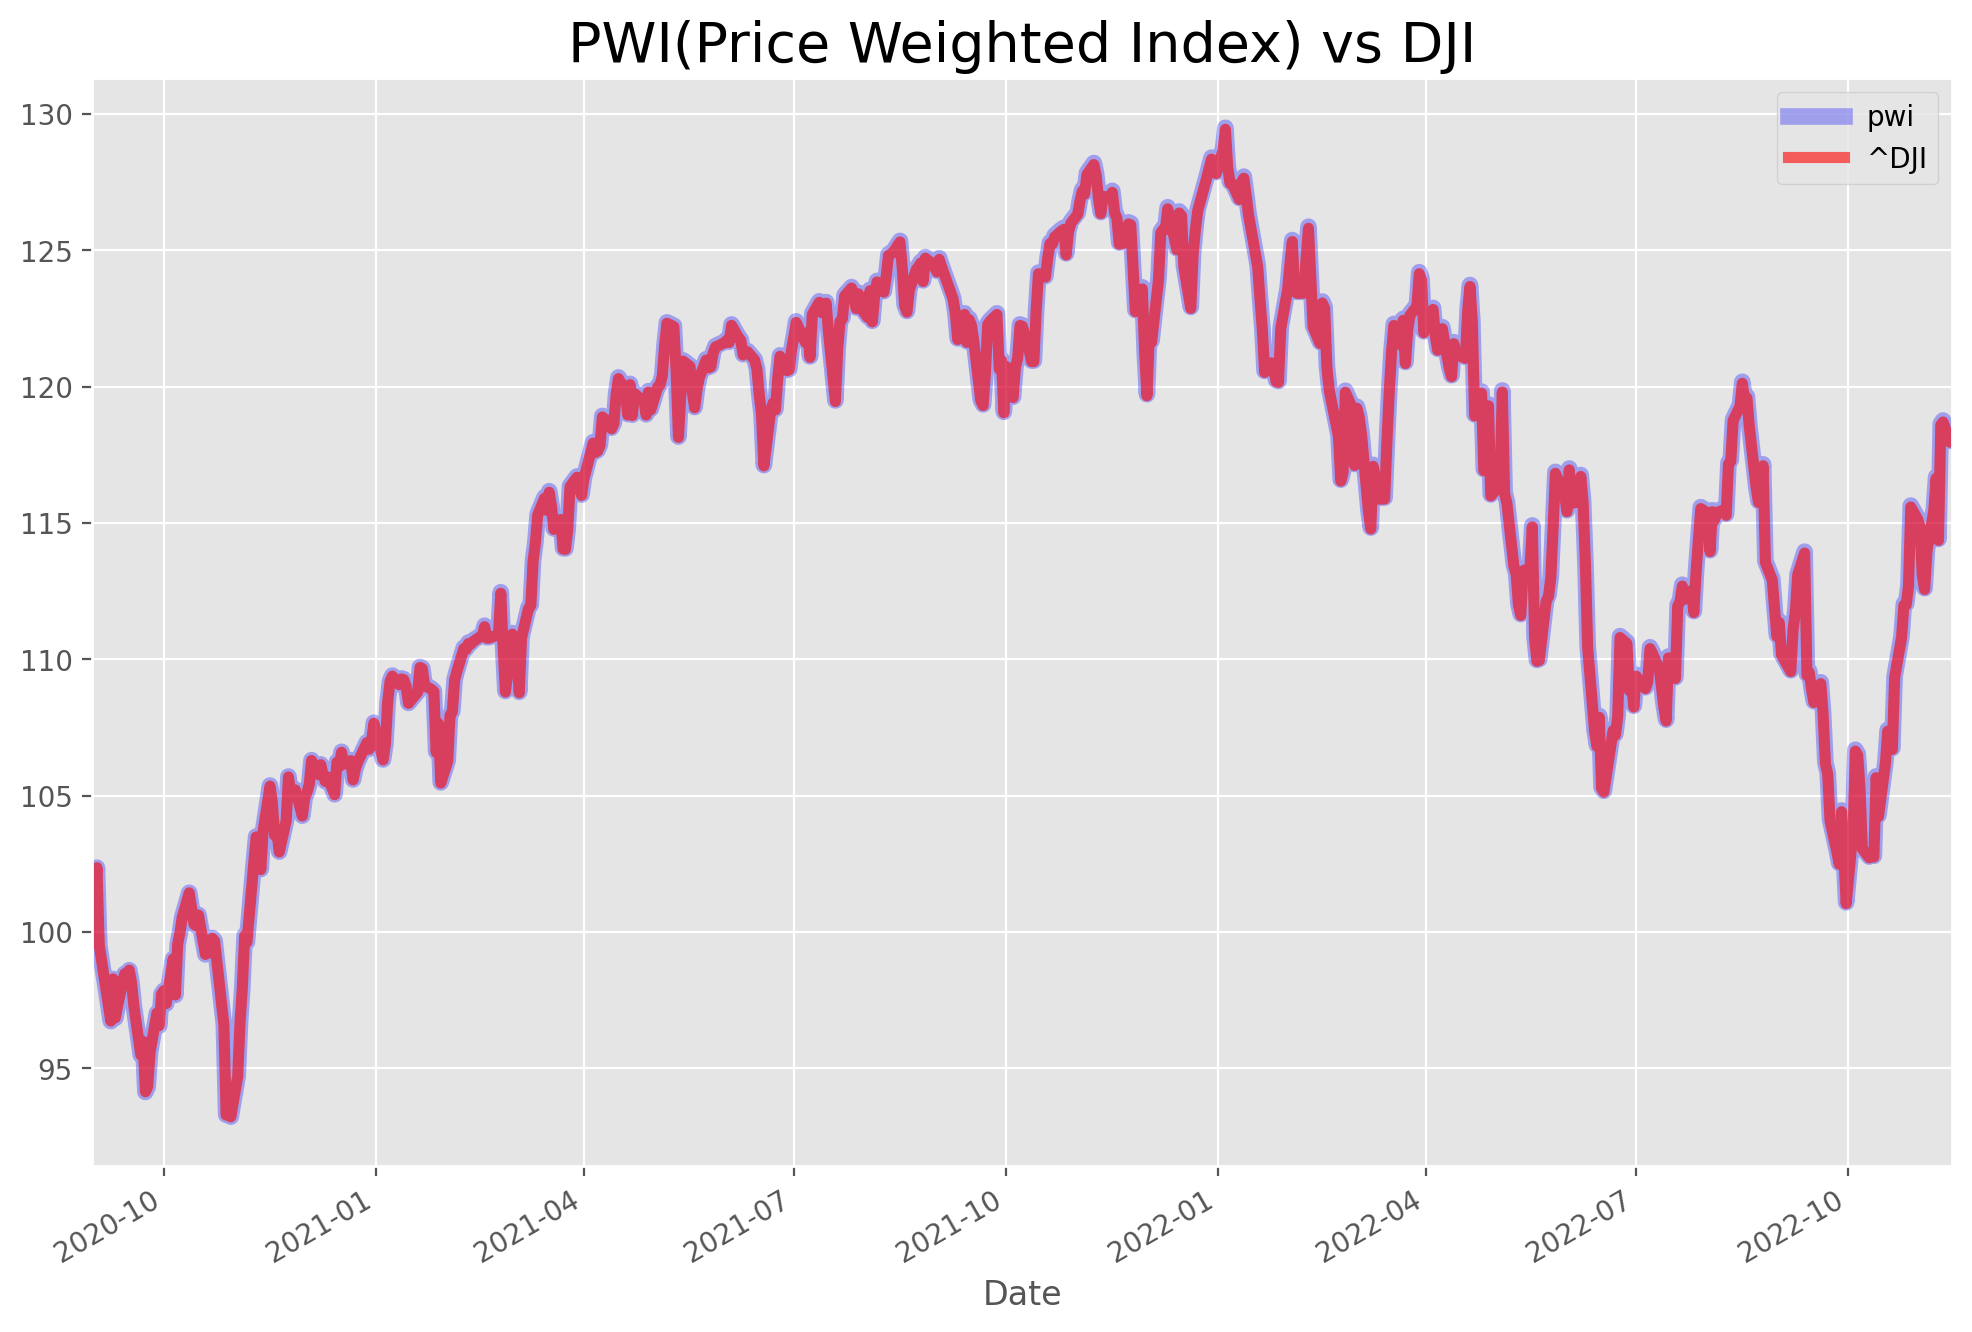

In [16]:
pwi.plot(figsize = (12, 8) , ls = "-", lw = 6 , alpha = 0.3 , color = "blue")
dji_norm.plot(ls = "-" , lw = 4 , alpha = 0.6 , color = "red")
plt.title("PWI(Price Weighted Index) vs DJI", fontsize = 20)
plt.legend()
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

__Weights over time__

In [17]:
close[const]

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,129.03999,253.32001,101.59000,171.82001,142.31000,272.64999,42.22000,83.93000,131.87000,45.12000,...,81.36450,225.53000,111.89000,138.33000,116.04000,312.54999,211.99001,59.27000,38.02000,138.85001
2020-09-01,134.17999,250.86000,102.47000,172.10001,146.05000,281.25000,42.03000,83.08000,133.55000,47.27000,...,80.56298,227.27000,114.84000,138.17999,114.69000,312.82999,213.35001,59.16000,36.76000,147.59000
2020-09-02,131.39999,258.12000,104.40000,174.78000,149.27000,276.69000,42.42000,83.19000,135.39000,49.22000,...,82.94847,231.64999,116.80000,140.50999,117.48000,320.23999,216.48000,60.53000,37.17000,147.67999
2020-09-03,120.88000,247.91000,104.46000,168.77000,146.75999,265.01001,40.95000,82.28000,133.24001,48.39000,...,81.57442,217.30000,112.85000,138.25999,115.35000,316.23001,208.96001,60.61000,37.09000,144.53999
2020-09-04,120.96000,248.39999,105.67000,171.05000,148.17999,254.70000,40.82000,81.93000,131.99001,48.60000,...,81.33588,214.25000,112.40000,137.96001,116.57000,312.00000,204.66000,60.48000,36.89000,142.83000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,134.87000,289.64999,145.86000,168.74001,225.53999,142.06000,43.91000,177.92999,86.75000,47.68000,...,101.59000,224.50999,92.10000,136.48000,182.14999,540.65997,193.92999,37.62000,36.89000,139.47000
2022-11-10,146.87000,291.01001,154.75000,177.58000,232.45000,156.30000,45.66000,181.30000,90.46000,49.96000,...,101.89000,242.98000,99.49000,141.17999,183.30000,544.16998,205.57001,38.52000,38.49000,142.36000
2022-11-11,149.70000,285.01999,154.89000,177.49001,236.49001,157.73000,44.79000,186.46001,95.01000,53.14000,...,97.96000,247.11000,106.09000,140.97000,181.73000,522.08002,205.00000,38.30000,41.26000,142.58000


In [18]:
close[const].sum(axis = 1) # closing prices at the end of each day

Date
2020-08-31   4311.67171
2020-09-01   4344.47622
2020-09-02   4413.28146
2020-09-03   4290.74151
2020-09-04   4266.61749
                ...    
2022-11-09   4933.25994
2022-11-10   5115.55000
2022-11-11   5120.48003
2022-11-14   5088.43999
2022-11-15   5096.97002
Length: 558, dtype: float64

In [19]:
total_daily_close = close[const].sum(axis = 1)
total_daily_close

Date
2020-08-31   4311.67171
2020-09-01   4344.47622
2020-09-02   4413.28146
2020-09-03   4290.74151
2020-09-04   4266.61749
                ...    
2022-11-09   4933.25994
2022-11-10   5115.55000
2022-11-11   5120.48003
2022-11-14   5088.43999
2022-11-15   5096.97002
Length: 558, dtype: float64

In [26]:
weights_PWI = close[const].div(total_daily_close, 
                               axis = 0)
weights_PWI

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,0.02993,0.05875,0.02356,0.03985,0.03301,0.06324,0.00979,0.01947,0.03058,0.01046,...,0.01887,0.05231,0.02595,0.03208,0.02691,0.07249,0.04917,0.01375,0.00882,0.03220
2020-09-01,0.03089,0.05774,0.02359,0.03961,0.03362,0.06474,0.00967,0.01912,0.03074,0.01088,...,0.01854,0.05231,0.02643,0.03181,0.02640,0.07201,0.04911,0.01362,0.00846,0.03397
2020-09-02,0.02977,0.05849,0.02366,0.03960,0.03382,0.06269,0.00961,0.01885,0.03068,0.01115,...,0.01880,0.05249,0.02647,0.03184,0.02662,0.07256,0.04905,0.01372,0.00842,0.03346
2020-09-03,0.02817,0.05778,0.02435,0.03933,0.03420,0.06176,0.00954,0.01918,0.03105,0.01128,...,0.01901,0.05064,0.02630,0.03222,0.02688,0.07370,0.04870,0.01413,0.00864,0.03369
2020-09-04,0.02835,0.05822,0.02477,0.04009,0.03473,0.05970,0.00957,0.01920,0.03094,0.01139,...,0.01906,0.05022,0.02634,0.03233,0.02732,0.07313,0.04797,0.01418,0.00865,0.03348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,0.02734,0.05871,0.02957,0.03420,0.04572,0.02880,0.00890,0.03607,0.01758,0.00967,...,0.02059,0.04551,0.01867,0.02767,0.03692,0.10959,0.03931,0.00763,0.00748,0.02827
2022-11-10,0.02871,0.05689,0.03025,0.03471,0.04544,0.03055,0.00893,0.03544,0.01768,0.00977,...,0.01992,0.04750,0.01945,0.02760,0.03583,0.10638,0.04019,0.00753,0.00752,0.02783
2022-11-11,0.02924,0.05566,0.03025,0.03466,0.04619,0.03080,0.00875,0.03641,0.01855,0.01038,...,0.01913,0.04826,0.02072,0.02753,0.03549,0.10196,0.04004,0.00748,0.00806,0.02785


In [27]:
weights_PWI.sum(axis =1)

Date
2020-08-31   1.00000
2020-09-01   1.00000
2020-09-02   1.00000
2020-09-03   1.00000
2020-09-04   1.00000
               ...  
2022-11-09   1.00000
2022-11-10   1.00000
2022-11-11   1.00000
2022-11-14   1.00000
2022-11-15   1.00000
Length: 558, dtype: float64

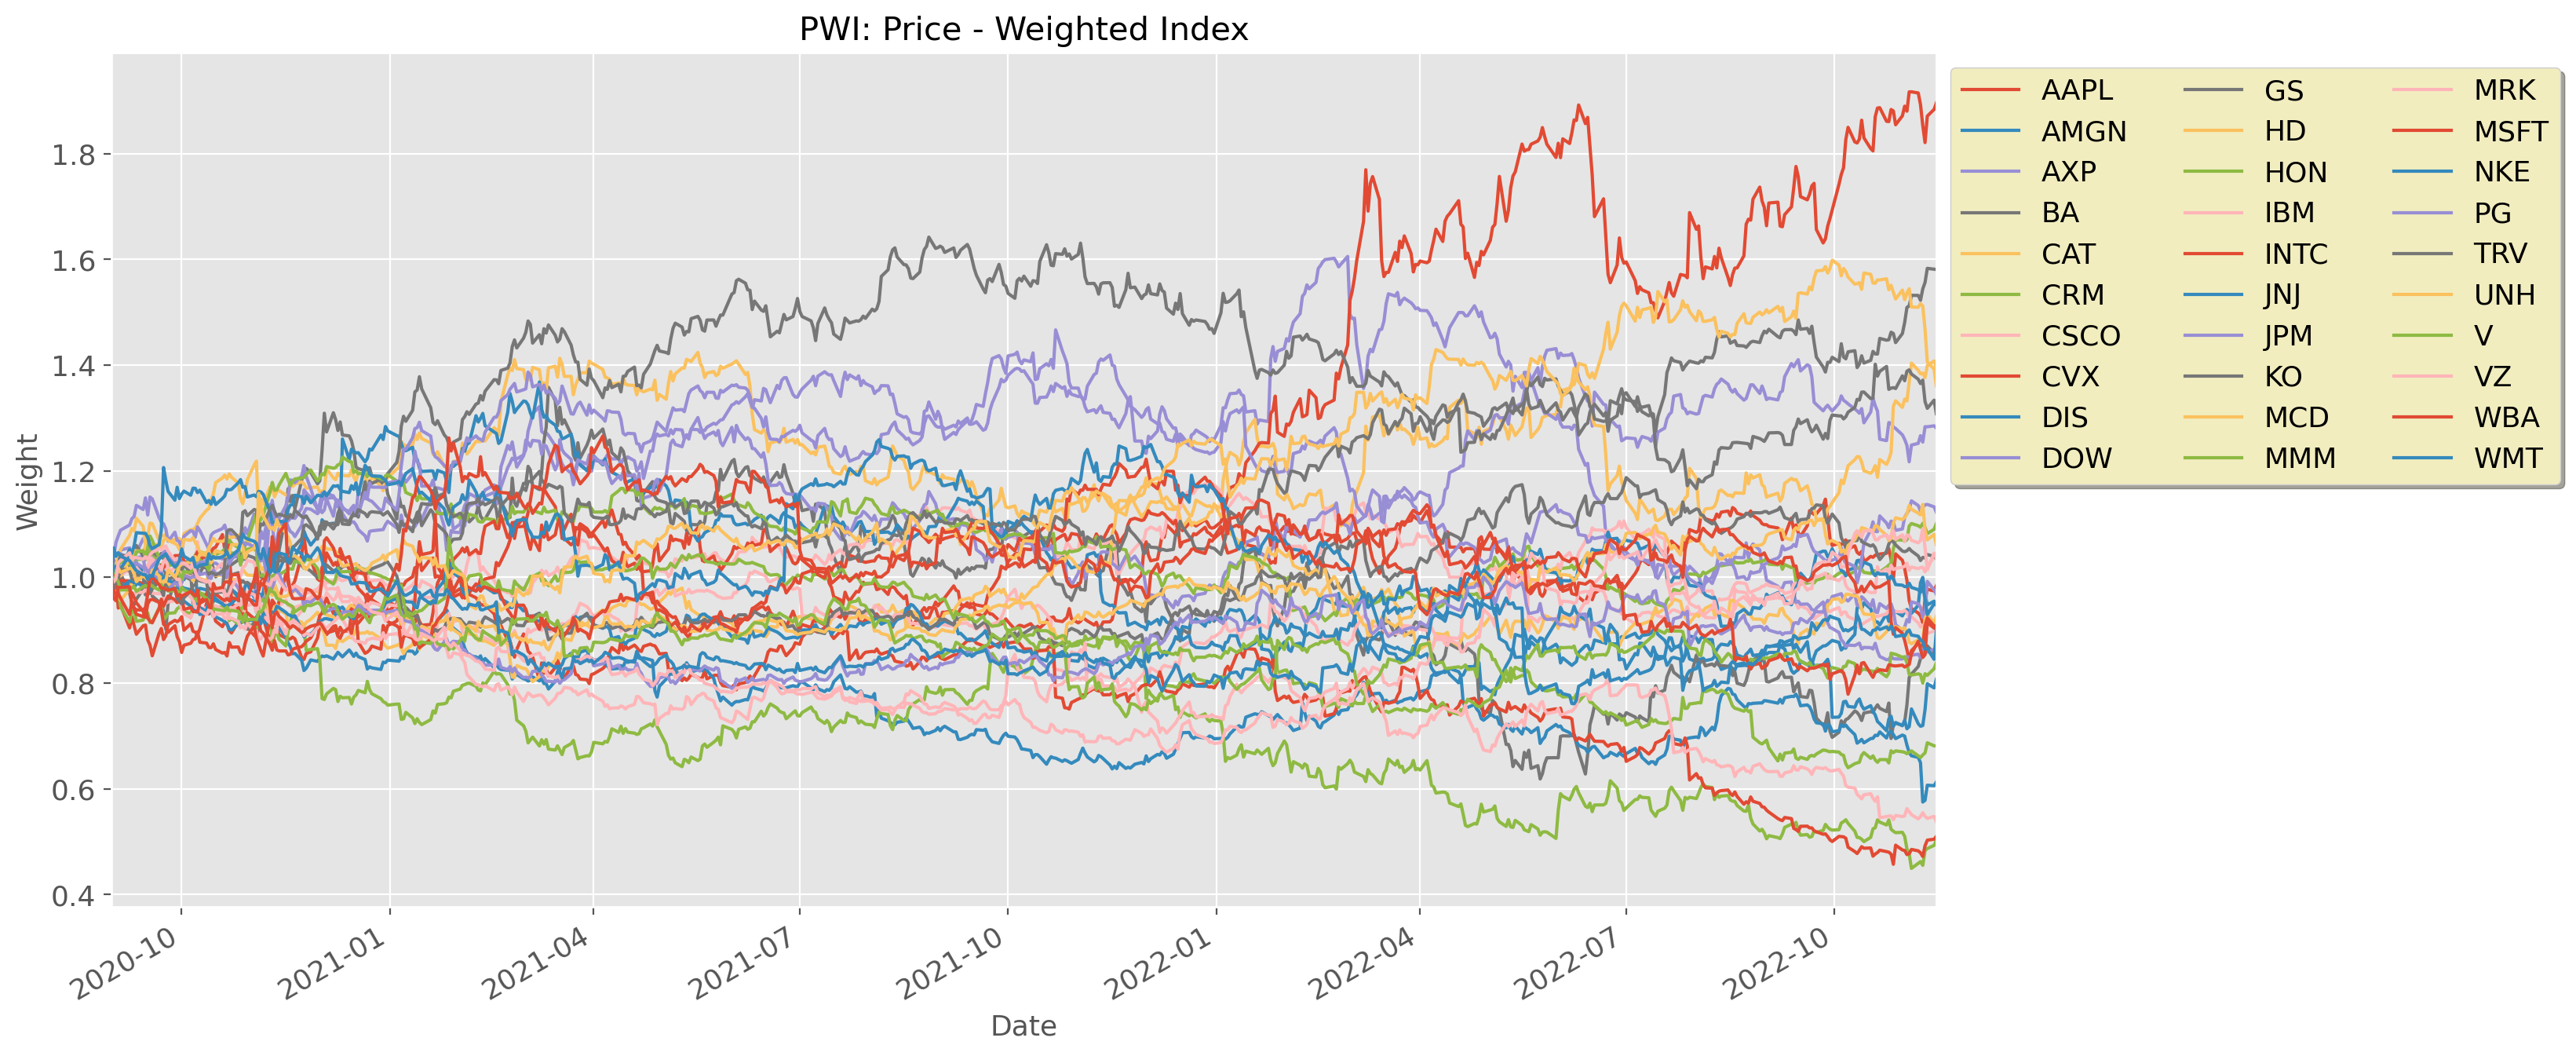

In [28]:
weights_PWI.div(weights_PWI.iloc[0]).plot(figsize = (15, 8), fontsize = 13)
plt.title("PWI: Price - Weighted Index", fontsize = 15)
plt.xlabel("Date", fontsize = 13)
plt.ylabel("Weight", fontsize = 13)
plt.legend(fontsize = 13 , bbox_to_anchor = (1, 1) , ncol = len(const)/9 , fancybox = True , shadow = True , frameon = True , facecolor =  "#F1EDBF")
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

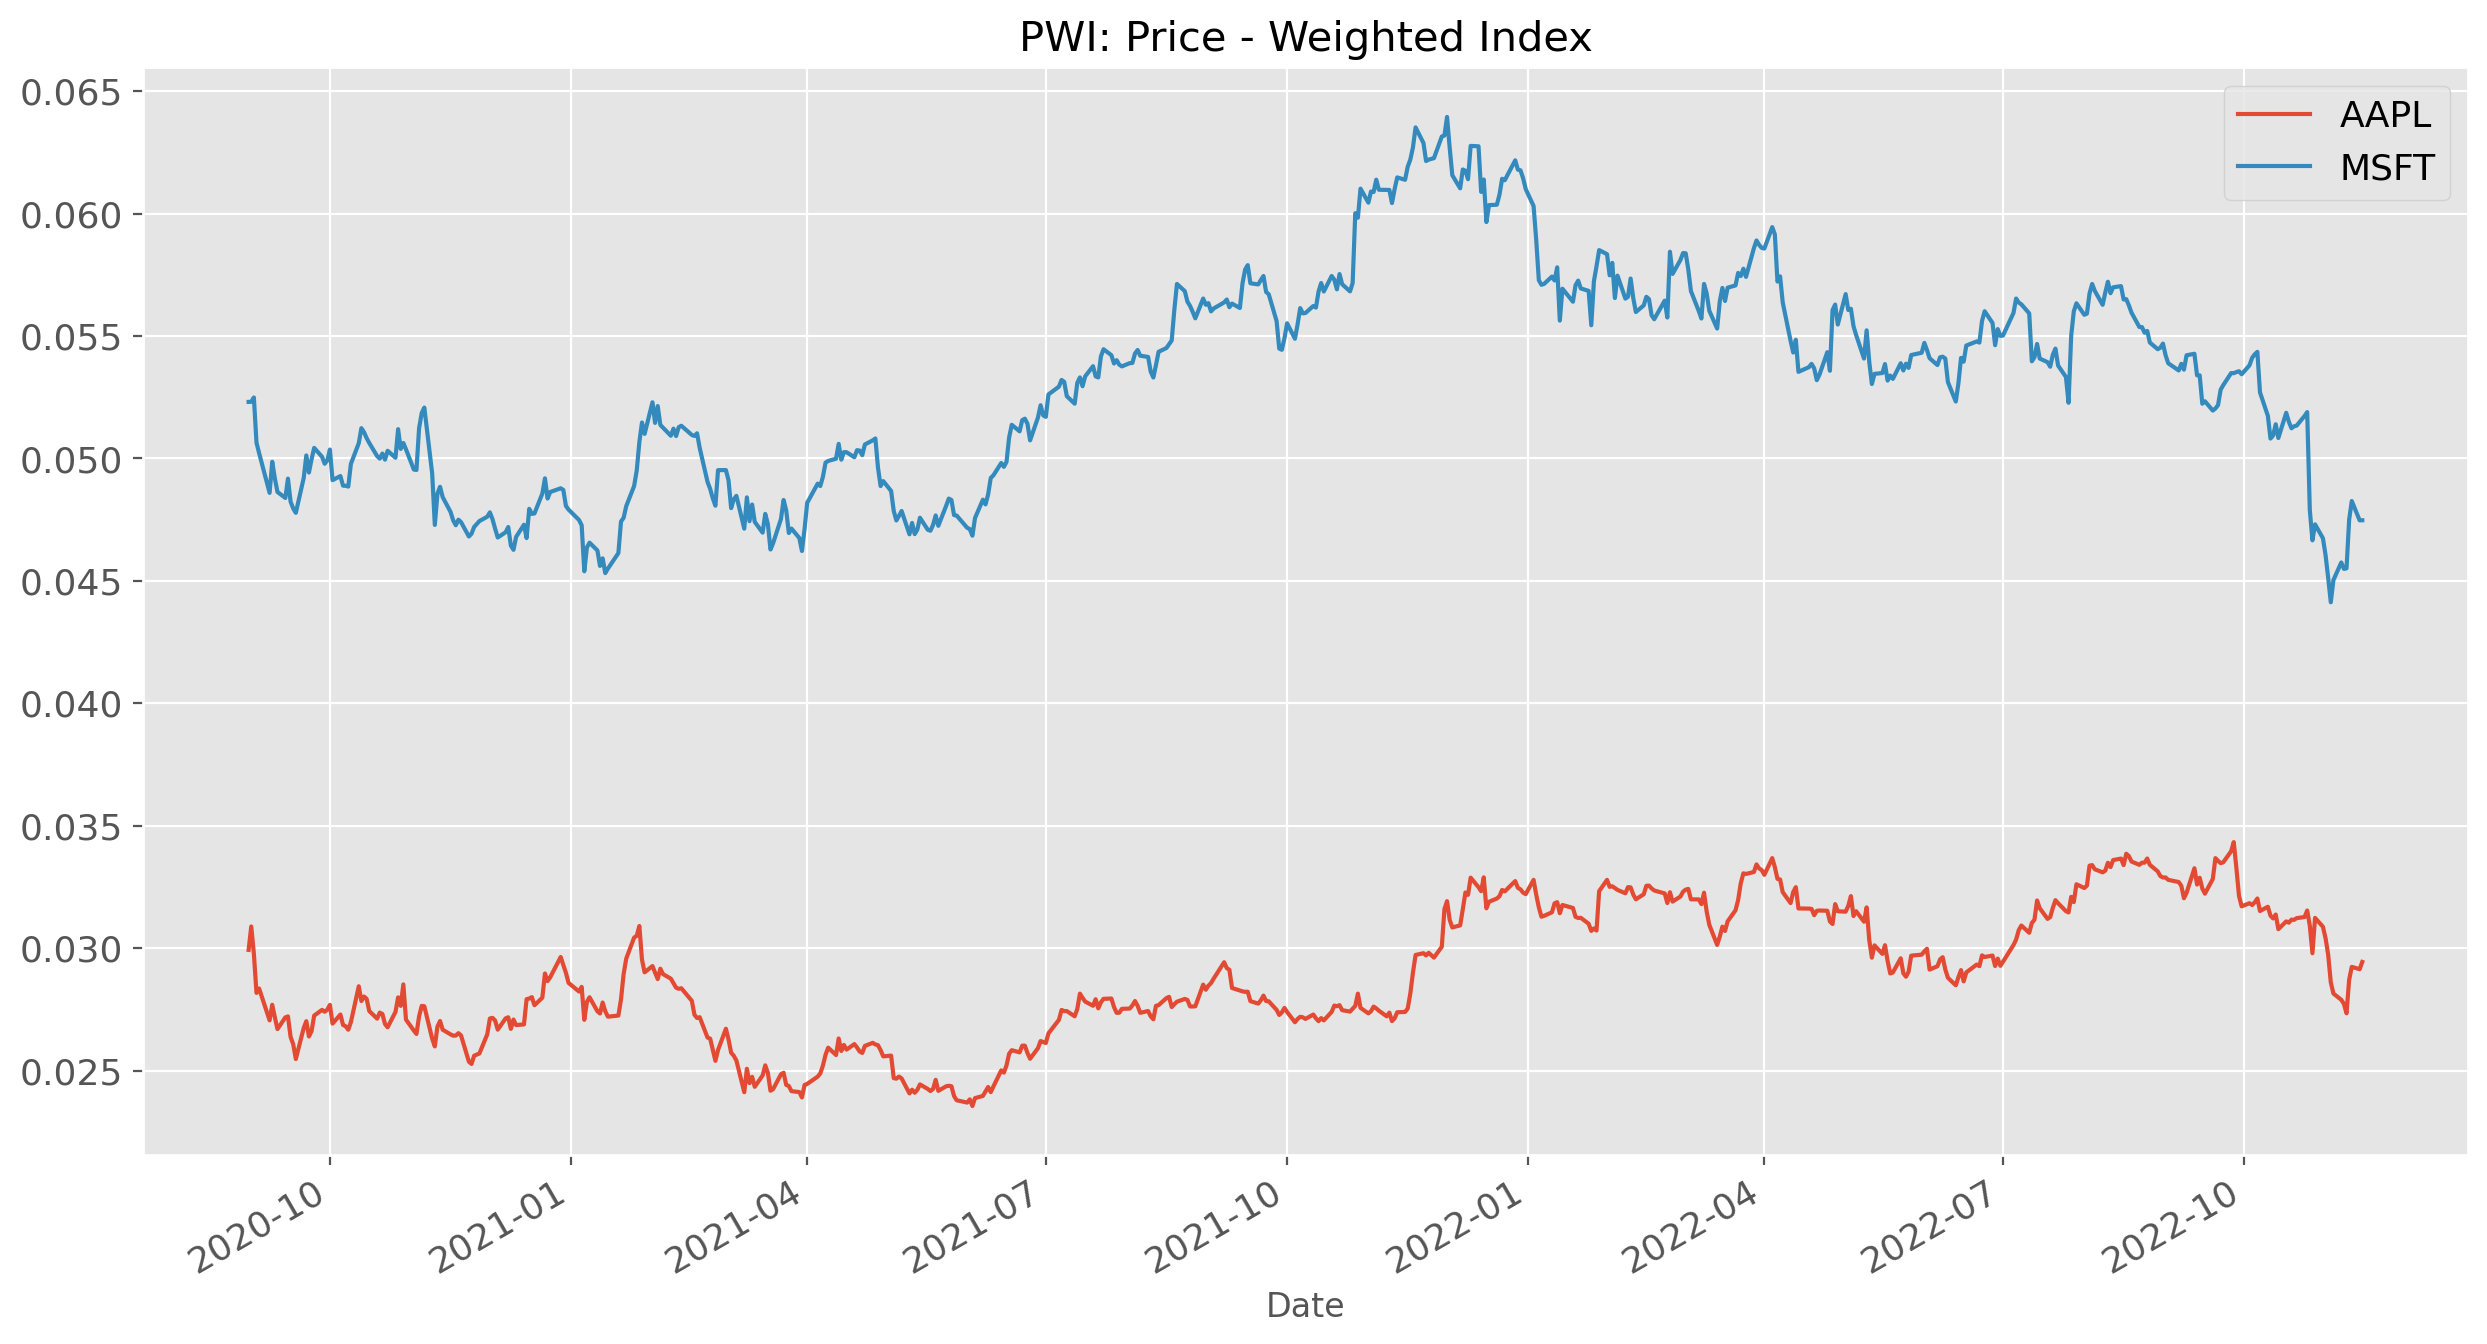

In [24]:
weights_PWI[["AAPL", "MSFT"]].plot(figsize = (15, 8), fontsize = 13)
plt.title("PWI: Price - Weighted Index", fontsize = 15)
plt.legend(fontsize = 13)
plt.show()

## Building an Equal-weighted Index

In [29]:
returns

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,0.03983,-0.00971,0.00866,0.00163,0.02628,0.03154,-0.00450,-0.01013,0.01274,0.04765,...,0.00772,0.02637,-0.00108,-0.01163,0.00090,0.00642,-0.00186,-0.03314,0.06295,0.00758
2020-09-02,-0.02072,0.02894,0.01883,0.01557,0.02205,-0.01621,0.00928,0.00132,0.01378,0.04125,...,0.01927,0.01707,0.01686,0.02433,0.02369,0.01467,0.02316,0.01115,0.00061,0.01588
2020-09-03,-0.08006,-0.03956,0.00057,-0.03439,-0.01682,-0.04221,-0.03465,-0.01094,-0.01588,-0.01686,...,-0.06195,-0.03382,-0.01601,-0.01813,-0.01252,-0.03474,0.00132,-0.00215,-0.02126,-0.02776
2020-09-04,0.00066,0.00198,0.01158,0.01351,0.00968,-0.03890,-0.00317,-0.00425,-0.00938,0.00434,...,-0.01404,-0.00399,-0.00217,0.01058,-0.01338,-0.02058,-0.00214,-0.00539,-0.01183,-0.00563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.03319,-0.00937,-0.02889,-0.00519,-0.01858,-0.03426,-0.01569,-0.03998,-0.13163,-0.03968,...,-0.01905,-0.01760,-0.00241,-0.01487,-0.02240,-0.03890,-0.00660,-0.03656,-0.02325,-0.01951
2022-11-10,0.08897,0.00470,0.06095,0.05239,0.03064,0.10024,0.03985,0.01894,0.04277,0.04782,...,0.08227,0.08024,0.03444,0.00631,0.00649,0.06002,0.02392,0.04337,0.02072,0.03695
2022-11-11,0.01927,-0.02058,0.00090,-0.00051,0.01738,0.00915,-0.01905,0.02846,0.05030,0.06365,...,0.01700,0.06634,-0.00149,-0.00857,-0.04059,-0.00277,-0.00571,0.07197,0.00155,0.00096


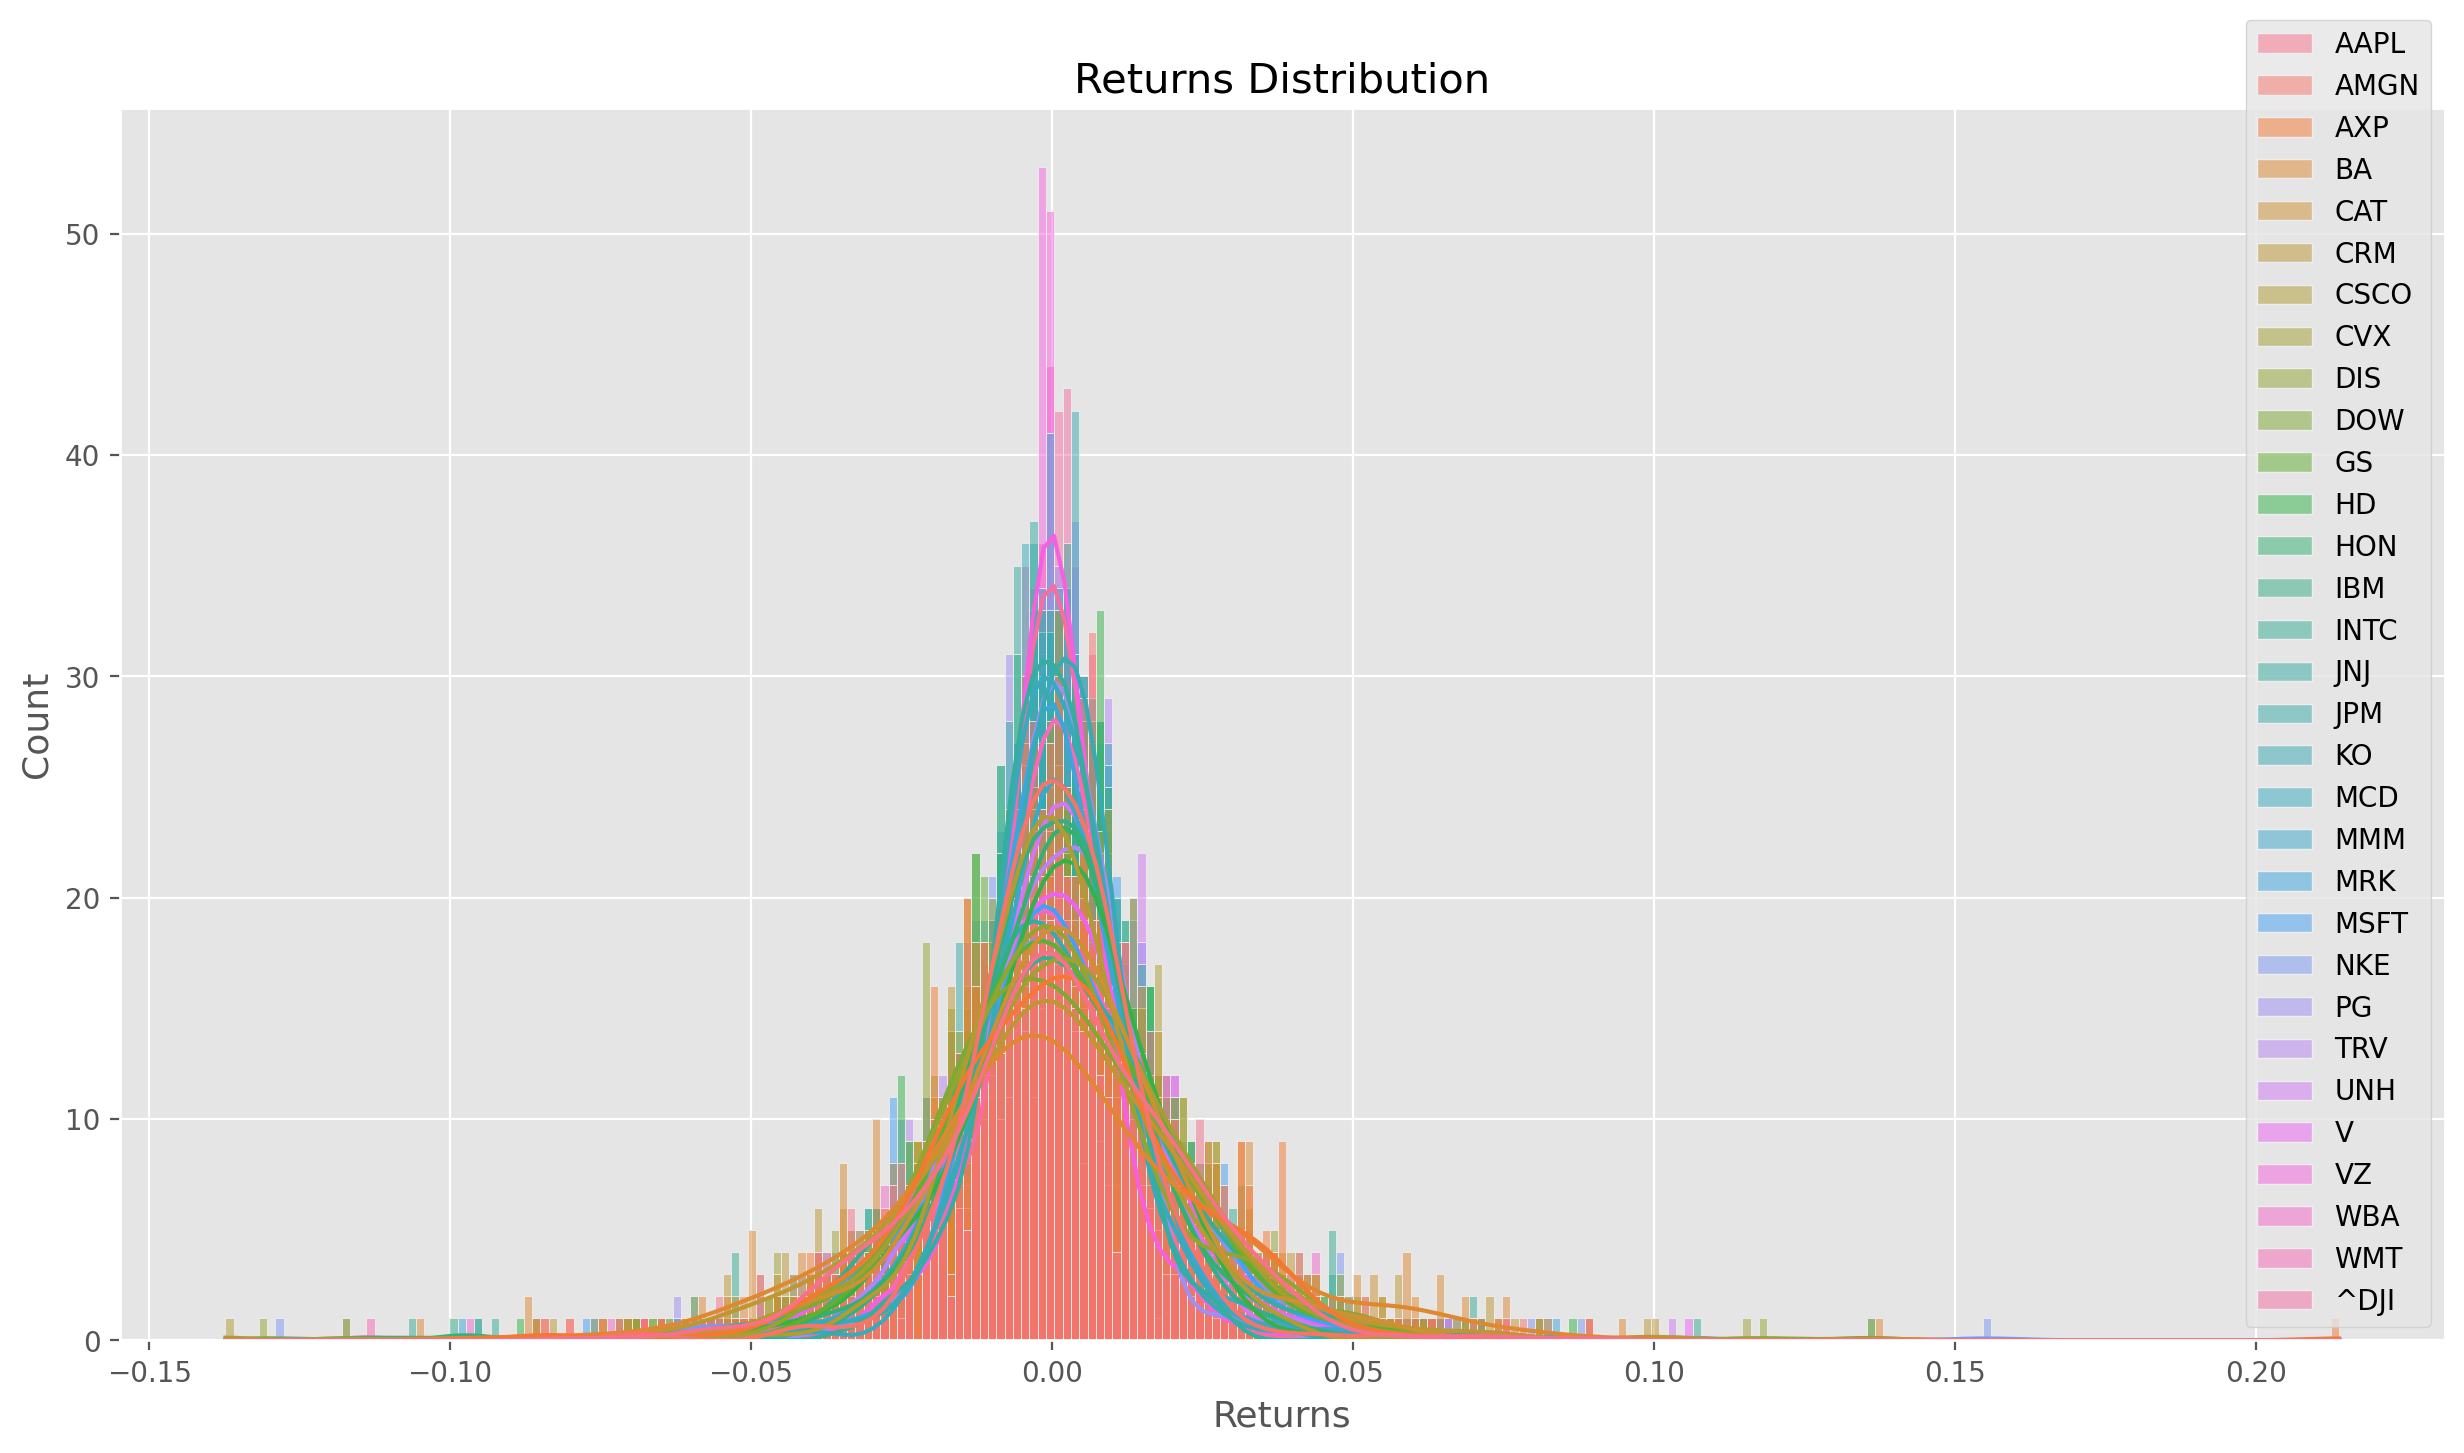

In [123]:
plt.figure(figsize = (15, 8))
sns.histplot(data = returns, kde = True , alpha = 0.5)
plt.title("Returns Distribution", fontsize = 15)
plt.xlabel("Returns", fontsize = 13)
plt.ylabel("Count", fontsize = 13)
plt.show()

In [ ]:
mean_ret_daily = returns[const].mean(axis = 1) # mean returns daily
mean_ret_daily

Date
2020-08-31        NaN
2020-09-01    0.00650
2020-09-02    0.01777
2020-09-03   -0.02459
2020-09-04   -0.00298
               ...   
2022-11-09   -0.02242
2022-11-10    0.04146
2022-11-11    0.00852
2022-11-14   -0.00550
2022-11-15    0.00363
Length: 558, dtype: float64

In [31]:
ewi = mean_ret_daily.add(1).cumprod().mul(100) # equal weighted index EWI
ewi

Date
2020-08-31         NaN
2020-09-01   100.64983
2020-09-02   102.43863
2020-09-03    99.91993
2020-09-04    99.62227
                ...   
2022-11-09   113.09603
2022-11-10   117.78518
2022-11-11   118.78860
2022-11-14   118.13493
2022-11-15   118.56409
Length: 558, dtype: float64

In [32]:
ewi.iloc[0] = 100

In [34]:
ewi.name = "ewi"
ewi

Date
2020-08-31   100.00000
2020-09-01   100.64983
2020-09-02   102.43863
2020-09-03    99.91993
2020-09-04    99.62227
                ...   
2022-11-09   113.09603
2022-11-10   117.78518
2022-11-11   118.78860
2022-11-14   118.13493
2022-11-15   118.56409
Name: ewi, Length: 558, dtype: float64

## Building a Value-weighted Index (Part 1)

__Historical Market Caps__

- Hard to get from free Web Soruces
- Still, we can calculate an approximation with yahoo finance data
- Course might cover a paid data source with historical market caps

In [38]:
import yfinance as yf
from yahooquery import Ticker

In [39]:
const

Index(['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'DOW',
       'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM',
       'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WBA', 'WMT'],
      dtype='object')

In [40]:
ticker = yf.Ticker(ticker = "AAPL") #yfinance
ticker

yfinance.Ticker object <AAPL>

In [42]:
info = pd.Series(ticker.get_info()) # yfinance
info

address1                      One Apple Park Way
city                                   Cupertino
state                                         CA
zip                                        95014
country                            United States
                                     ...        
hasPrePostMarketData                        True
firstTradeDateMilliseconds          345479400000
marketState                                 POST
displayName                                Apple
trailingPegRatio                         2.49090
Length: 187, dtype: object

In [43]:
shares = info["sharesOutstanding"] #yfinance
shares

14594180000

In [44]:
shares = Ticker("AAPL").key_stats["AAPL"]["sharesOutstanding"] #yahooquery
shares

14594180000

In [45]:
mcap = close.AAPL * shares
mcap

Date
2020-08-31   1883232889216.61377
2020-09-01   1958246965509.03320
2020-09-02   1917675162924.19434
2020-09-03   1764144438315.88721
2020-09-04   1765311999438.62915
                     ...        
2022-11-09   1968316985339.35547
2022-11-10   2143447145339.35547
2022-11-11   2184748701462.09717
2022-11-14   2164024992584.83887
2022-11-15   2189710669216.61377
Name: AAPL, Length: 558, dtype: float64

In [46]:
close.index

DatetimeIndex(['2020-08-31', '2020-09-01', '2020-09-02', '2020-09-03',
               '2020-09-04', '2020-09-08', '2020-09-09', '2020-09-10',
               '2020-09-11', '2020-09-14',
               ...
               '2022-11-02', '2022-11-03', '2022-11-04', '2022-11-07',
               '2022-11-08', '2022-11-09', '2022-11-10', '2022-11-11',
               '2022-11-14', '2022-11-15'],
              dtype='datetime64[ns]', name='Date', length=558, freq=None)

(Simplified) Assumption: __Outstanding Shares remained constant__ in the most recent time period (no new share issues or buy-backs)

In [52]:
mcap = pd.DataFrame(index = close.index, columns = const) # dummy df to insert mcaps
mcap

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
# yfinance (recommended)
count = 1
for symbol in const:
    try:
        shares = yf.Ticker(ticker = symbol).get_info()["sharesOutstanding"]
        mcap[symbol] = close[symbol] * shares
        print(count, end = '\r')
        count += 1
    except Exception as e:
        print("{} not found".format(symbol))
print("Download complete.")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


WBA not found
Download complete.


In [60]:
mcap

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,1883232889216.61377,136952903466.30707,68604723461.41153,135801382625.24292,65416332331.33685,224390944976.80664,166407376367.62161,164637363385.45380,227698193335.65161,32592012108.77688,...,200740191558.74561,1674683265520.84351,134504193573.67970,321295265171.90002,24203045743.83614,280543258472.88165,361254859362.03064,246253528124.44516,NaN,1104979339244.01050
2020-09-01,1958246965509.03320,135622945104.27560,69198999411.86282,136022685266.03577,67135518941.26643,231468750000.00000,165658494158.62842,162970003595.72287,230599041031.53024,34145045739.63134,...,198762700937.00055,1687603755464.92285,138050417210.57822,320946843060.39990,23921469782.39636,280794583934.34485,363572453665.97839,245796500316.35162,NaN,1174532873343.09375
2020-09-02,1917675162924.19434,139547930490.79529,70502347595.64102,138140871130.79285,68615672644.97301,227715872009.27734,167195651272.31757,163185781153.13049,233776138607.89395,35553610677.18356,...,204648115237.72916,1720127567668.21729,140406562745.35147,326358673800.29993,24503394284.73250,287445765037.70532,368906308716.36505,251488537905.31296,NaN,1175249071323.68750
2020-09-03,1764144438315.88721,134028082339.40352,70542864536.91537,133390751652.22504,67461884184.57042,218103238037.10938,161401752538.82602,161400714990.18475,230063772307.45444,34954066564.40822,...,201258107113.70447,1613571057855.26636,135658218986.07425,321132661098.29993,24059128469.43977,283846428328.08154,356091399979.42627,251820927529.09354,NaN,1150260707634.21338
2020-09-04,1765311999438.62915,134292986742.24413,71359988816.58078,135192794333.01788,68114621685.26056,209618097488.40332,160889361822.46960,160714156837.45380,227905413679.95444,35105757452.39554,...,200669567565.93420,1590923121446.75000,135117272726.67575,320435887757.63342,24313590250.88795,280049592264.00000,348763710194.68701,251280802315.05484,NaN,1136652460280.32812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,1968316985339.35547,156594056948.49411,98500692653.55641,133367041516.43219,103675071378.86385,116915377990.72266,173068395538.73480,349028056175.60852,149790088748.50000,34441205320.92089,...,250639957669.36761,1667109177394.67065,110714416752.82425,316998307218.23328,37991938984.25910,485293605873.68964,330478562266.12585,156302638661.46130,NaN,1109913309462.30200
2022-11-10,2143447145339.35547,157329325054.65942,104504196656.75000,140353909598.81073,106851426545.23357,128634902511.59668,179965906202.48480,355638679562.53809,156196095574.09094,36088141260.23733,...,251380116689.97794,1804259011677.82666,119598015947.00394,327914859996.39990,38231802169.12045,488444172552.23431,350314458986.87415,160041942682.94516,NaN,1132912153363.02612
2022-11-11,2184748701462.09717,154090928125.53940,104598739621.19359,140282779191.43219,108708517024.67960,129811786483.76465,176536862253.84122,365760559639.98389,164052526247.62119,38385184941.65822,...,241684131399.71692,1834926550813.20361,127531946389.32822,327427118657.93335,37904337856.93136,468616333061.51569,349343102270.00000,159127887066.75809,NaN,1134662940491.57812


In [57]:
# # yahooquery (slow)
# count = 1
# for symbol in const:
#     try:
#         shares = Ticker(symbols = symbol).key_stats[symbol]["sharesOutstanding"]
#         mcap[symbol] = mcap[symbol] * shares
#         print(count, end = '\r')
#         count += 1
#     except Exception as e:
#         print("{} not found".format(symbol))
# print("Download complete.")

In [63]:
mcap.iloc[-1].to_frame().T

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
2022-11-15,2189710669216.61377,153323239917.75589,103923429788.19359,138591387831.03577,107835130527.13029,133383616027.83203,176970422472.65201,368879501662.03809,164915869698.62119,37272779585.39554,...,245730291380.19482,1796759251521.65649,128277258480.64456,326312245871.70007,37439216449.00000,451499192755.04468,357846633974.03064,156635028285.24191,NaN,1173339210042.10425


In [64]:
mcap.iloc[-1].sort_values(ascending = False).to_frame().T

,AAPL,MSFT,WMT,UNH,JNJ,CVX,V,JPM,PG,HD,...,CRM,NKE,GS,CAT,AXP,HON,MMM,TRV,DOW,WBA
2022-11-15,2189710669216.61377,1796759251521.65649,1173339210042.10425,451499192755.04468,415442417665.94464,368879501662.03809,357846633974.03064,353379279253.01239,326312245871.70007,311209317730.88293,...,133383616027.83203,128277258480.64456,111483710116.77539,107835130527.13029,103923429788.19359,68278384032.96204,67673096188.28397,37439216449.00000,37272779585.39554,NaN


C:\Users\ahmad\AppData\Local\Temp\ipykernel_10224\3607726124.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mcap.iloc[-1].sort_values().dropna().plot.pie(pctdistance = .75 ,


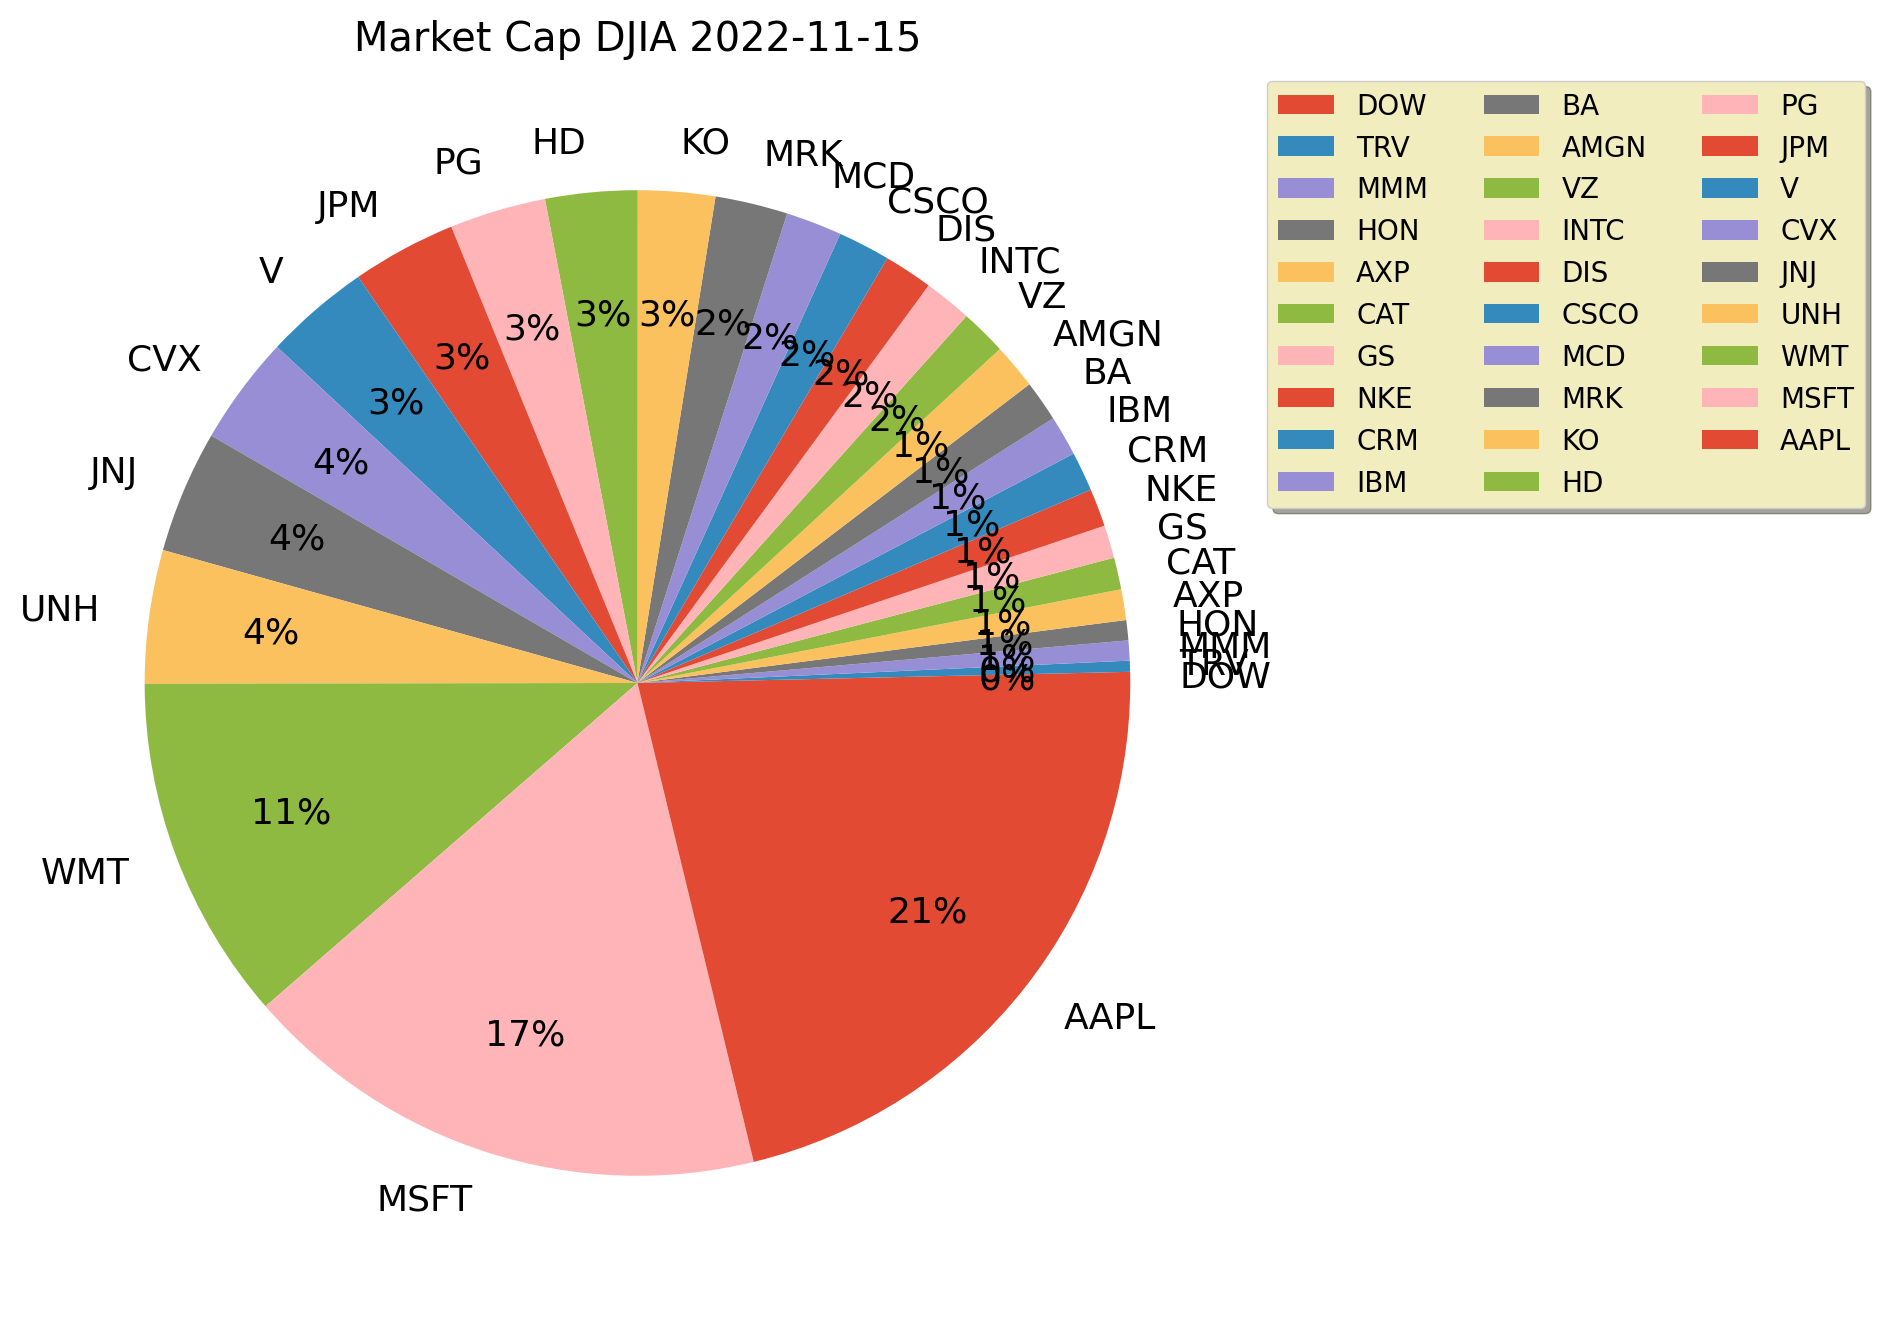

In [86]:
plt.figure(figsize = (12, 8))
mcap.iloc[-1].sort_values().dropna().plot.pie(pctdistance = .75 , 
                                              autopct = "%.0f%%", 
                                              fontsize = 13, 
                                              shadow = False, 
                                              legend = True, 
                                              title = "Market Cap DJIA 2022-11-15")
plt.ylabel("")
plt.legend(bbox_to_anchor = (1, 1) , ncol = len(const)/9 , fancybox = True , shadow = True , frameon = True , facecolor =  "#F1EDBF")
plt.show()

## Building a Value-weighted Index (Part 2)

In [87]:
mcap

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,1883232889216.61377,136952903466.30707,68604723461.41153,135801382625.24292,65416332331.33685,224390944976.80664,166407376367.62161,164637363385.45380,227698193335.65161,32592012108.77688,...,200740191558.74561,1674683265520.84351,134504193573.67970,321295265171.90002,24203045743.83614,280543258472.88165,361254859362.03064,246253528124.44516,NaN,1104979339244.01050
2020-09-01,1958246965509.03320,135622945104.27560,69198999411.86282,136022685266.03577,67135518941.26643,231468750000.00000,165658494158.62842,162970003595.72287,230599041031.53024,34145045739.63134,...,198762700937.00055,1687603755464.92285,138050417210.57822,320946843060.39990,23921469782.39636,280794583934.34485,363572453665.97839,245796500316.35162,NaN,1174532873343.09375
2020-09-02,1917675162924.19434,139547930490.79529,70502347595.64102,138140871130.79285,68615672644.97301,227715872009.27734,167195651272.31757,163185781153.13049,233776138607.89395,35553610677.18356,...,204648115237.72916,1720127567668.21729,140406562745.35147,326358673800.29993,24503394284.73250,287445765037.70532,368906308716.36505,251488537905.31296,NaN,1175249071323.68750
2020-09-03,1764144438315.88721,134028082339.40352,70542864536.91537,133390751652.22504,67461884184.57042,218103238037.10938,161401752538.82602,161400714990.18475,230063772307.45444,34954066564.40822,...,201258107113.70447,1613571057855.26636,135658218986.07425,321132661098.29993,24059128469.43977,283846428328.08154,356091399979.42627,251820927529.09354,NaN,1150260707634.21338
2020-09-04,1765311999438.62915,134292986742.24413,71359988816.58078,135192794333.01788,68114621685.26056,209618097488.40332,160889361822.46960,160714156837.45380,227905413679.95444,35105757452.39554,...,200669567565.93420,1590923121446.75000,135117272726.67575,320435887757.63342,24313590250.88795,280049592264.00000,348763710194.68701,251280802315.05484,NaN,1136652460280.32812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,1968316985339.35547,156594056948.49411,98500692653.55641,133367041516.43219,103675071378.86385,116915377990.72266,173068395538.73480,349028056175.60852,149790088748.50000,34441205320.92089,...,250639957669.36761,1667109177394.67065,110714416752.82425,316998307218.23328,37991938984.25910,485293605873.68964,330478562266.12585,156302638661.46130,NaN,1109913309462.30200
2022-11-10,2143447145339.35547,157329325054.65942,104504196656.75000,140353909598.81073,106851426545.23357,128634902511.59668,179965906202.48480,355638679562.53809,156196095574.09094,36088141260.23733,...,251380116689.97794,1804259011677.82666,119598015947.00394,327914859996.39990,38231802169.12045,488444172552.23431,350314458986.87415,160041942682.94516,NaN,1132912153363.02612
2022-11-11,2184748701462.09717,154090928125.53940,104598739621.19359,140282779191.43219,108708517024.67960,129811786483.76465,176536862253.84122,365760559639.98389,164052526247.62119,38385184941.65822,...,241684131399.71692,1834926550813.20361,127531946389.32822,327427118657.93335,37904337856.93136,468616333061.51569,349343102270.00000,159127887066.75809,NaN,1134662940491.57812


In [88]:
mcap.sum(axis = "columns")

Date
2020-08-31    9315387062823.73633
2020-09-01    9481196999329.90625
2020-09-02    9556651043356.61328
2020-09-03    9162798183718.86719
2020-09-04    9103067241450.63867
                     ...         
2022-11-09    9755425667181.26953
2022-11-10   10264981736213.60352
2022-11-11   10329715878355.15820
2022-11-14   10220935399584.49219
2022-11-15   10324832812903.88086
Length: 558, dtype: object

In [89]:
total_mcap = mcap.sum(axis = "columns") # total market cap for the day
total_mcap

Date
2020-08-31    9315387062823.73633
2020-09-01    9481196999329.90625
2020-09-02    9556651043356.61328
2020-09-03    9162798183718.86719
2020-09-04    9103067241450.63867
                     ...         
2022-11-09    9755425667181.26953
2022-11-10   10264981736213.60352
2022-11-11   10329715878355.15820
2022-11-14   10220935399584.49219
2022-11-15   10324832812903.88086
Length: 558, dtype: object

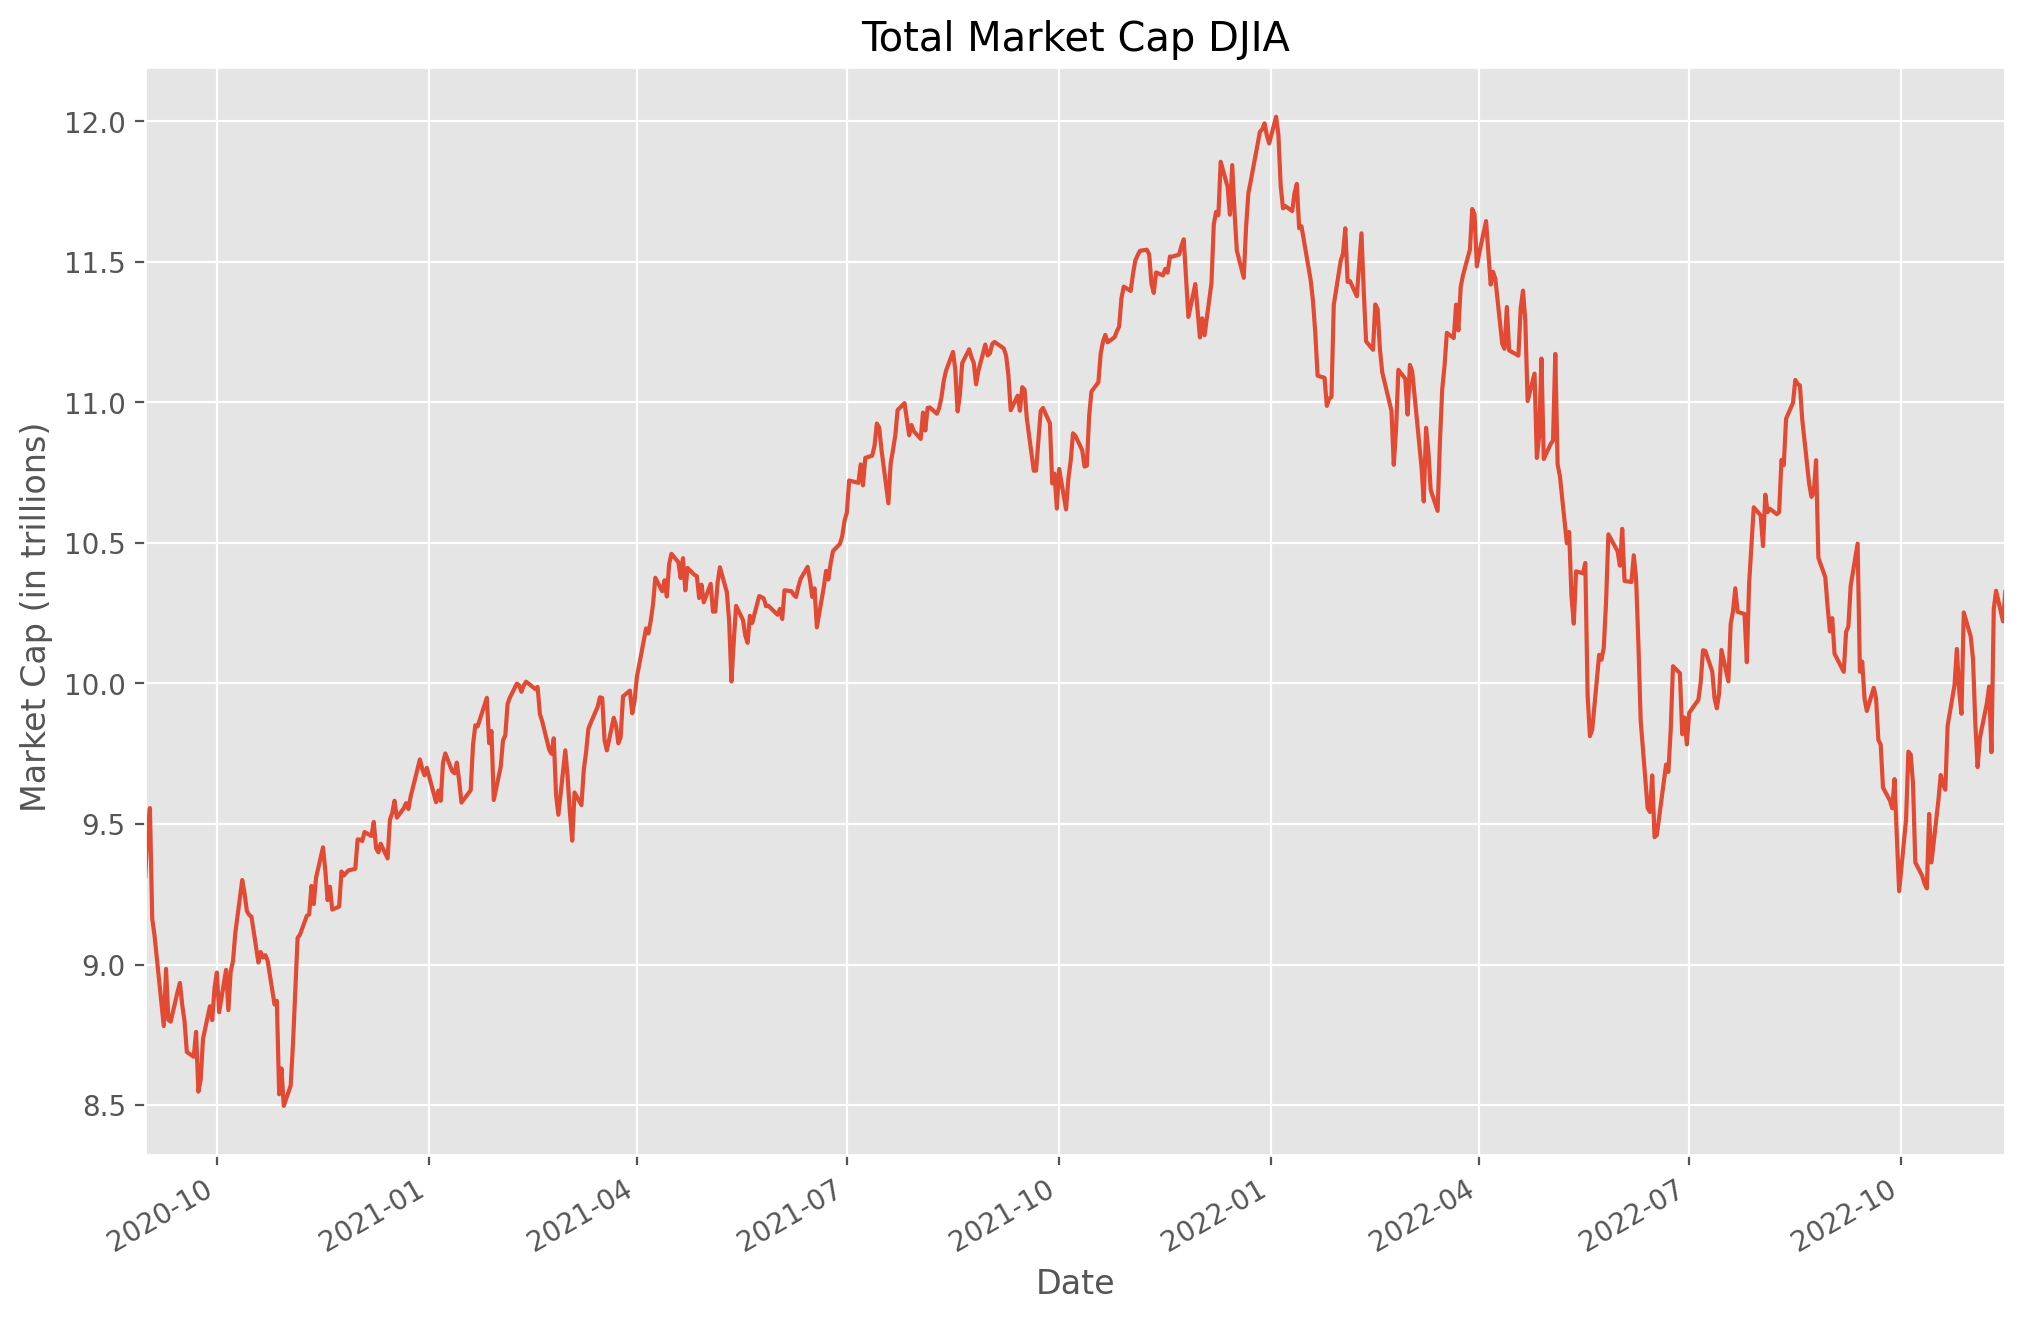

In [92]:
total_mcap.div(10**12).plot(figsize = (12, 8))
plt.title("Total Market Cap DJIA")
plt.ylabel("Market Cap (in trillions) ")
plt.xlabel("Date")
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

__Weights over time__

In [93]:
weights_VWI = mcap.div(total_mcap, axis = "rows")
weights_VWI

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,0.20216,0.01470,0.00736,0.01458,0.00702,0.02409,0.01786,0.01767,0.02444,0.00350,...,0.02155,0.17978,0.01444,0.03449,0.00260,0.03012,0.03878,0.02644,NaN,0.11862
2020-09-01,0.20654,0.01430,0.00730,0.01435,0.00708,0.02441,0.01747,0.01719,0.02432,0.00360,...,0.02096,0.17799,0.01456,0.03385,0.00252,0.02962,0.03835,0.02592,NaN,0.12388
2020-09-02,0.20066,0.01460,0.00738,0.01445,0.00718,0.02383,0.01750,0.01708,0.02446,0.00372,...,0.02141,0.17999,0.01469,0.03415,0.00256,0.03008,0.03860,0.02632,NaN,0.12298
2020-09-03,0.19253,0.01463,0.00770,0.01456,0.00736,0.02380,0.01761,0.01761,0.02511,0.00381,...,0.02196,0.17610,0.01481,0.03505,0.00263,0.03098,0.03886,0.02748,NaN,0.12554
2020-09-04,0.19392,0.01475,0.00784,0.01485,0.00748,0.02303,0.01767,0.01765,0.02504,0.00386,...,0.02204,0.17477,0.01484,0.03520,0.00267,0.03076,0.03831,0.02760,NaN,0.12486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,0.20177,0.01605,0.01010,0.01367,0.01063,0.01198,0.01774,0.03578,0.01535,0.00353,...,0.02569,0.17089,0.01135,0.03249,0.00389,0.04975,0.03388,0.01602,NaN,0.11377
2022-11-10,0.20881,0.01533,0.01018,0.01367,0.01041,0.01253,0.01753,0.03465,0.01522,0.00352,...,0.02449,0.17577,0.01165,0.03195,0.00372,0.04758,0.03413,0.01559,NaN,0.11037
2022-11-11,0.21150,0.01492,0.01013,0.01358,0.01052,0.01257,0.01709,0.03541,0.01588,0.00372,...,0.02340,0.17764,0.01235,0.03170,0.00367,0.04537,0.03382,0.01540,NaN,0.10984


In [94]:
weights_VWI.sum(axis = "columns")

Date
2020-08-31   1.00000
2020-09-01   1.00000
2020-09-02   1.00000
2020-09-03   1.00000
2020-09-04   1.00000
               ...  
2022-11-09   1.00000
2022-11-10   1.00000
2022-11-11   1.00000
2022-11-14   1.00000
2022-11-15   1.00000
Length: 558, dtype: object

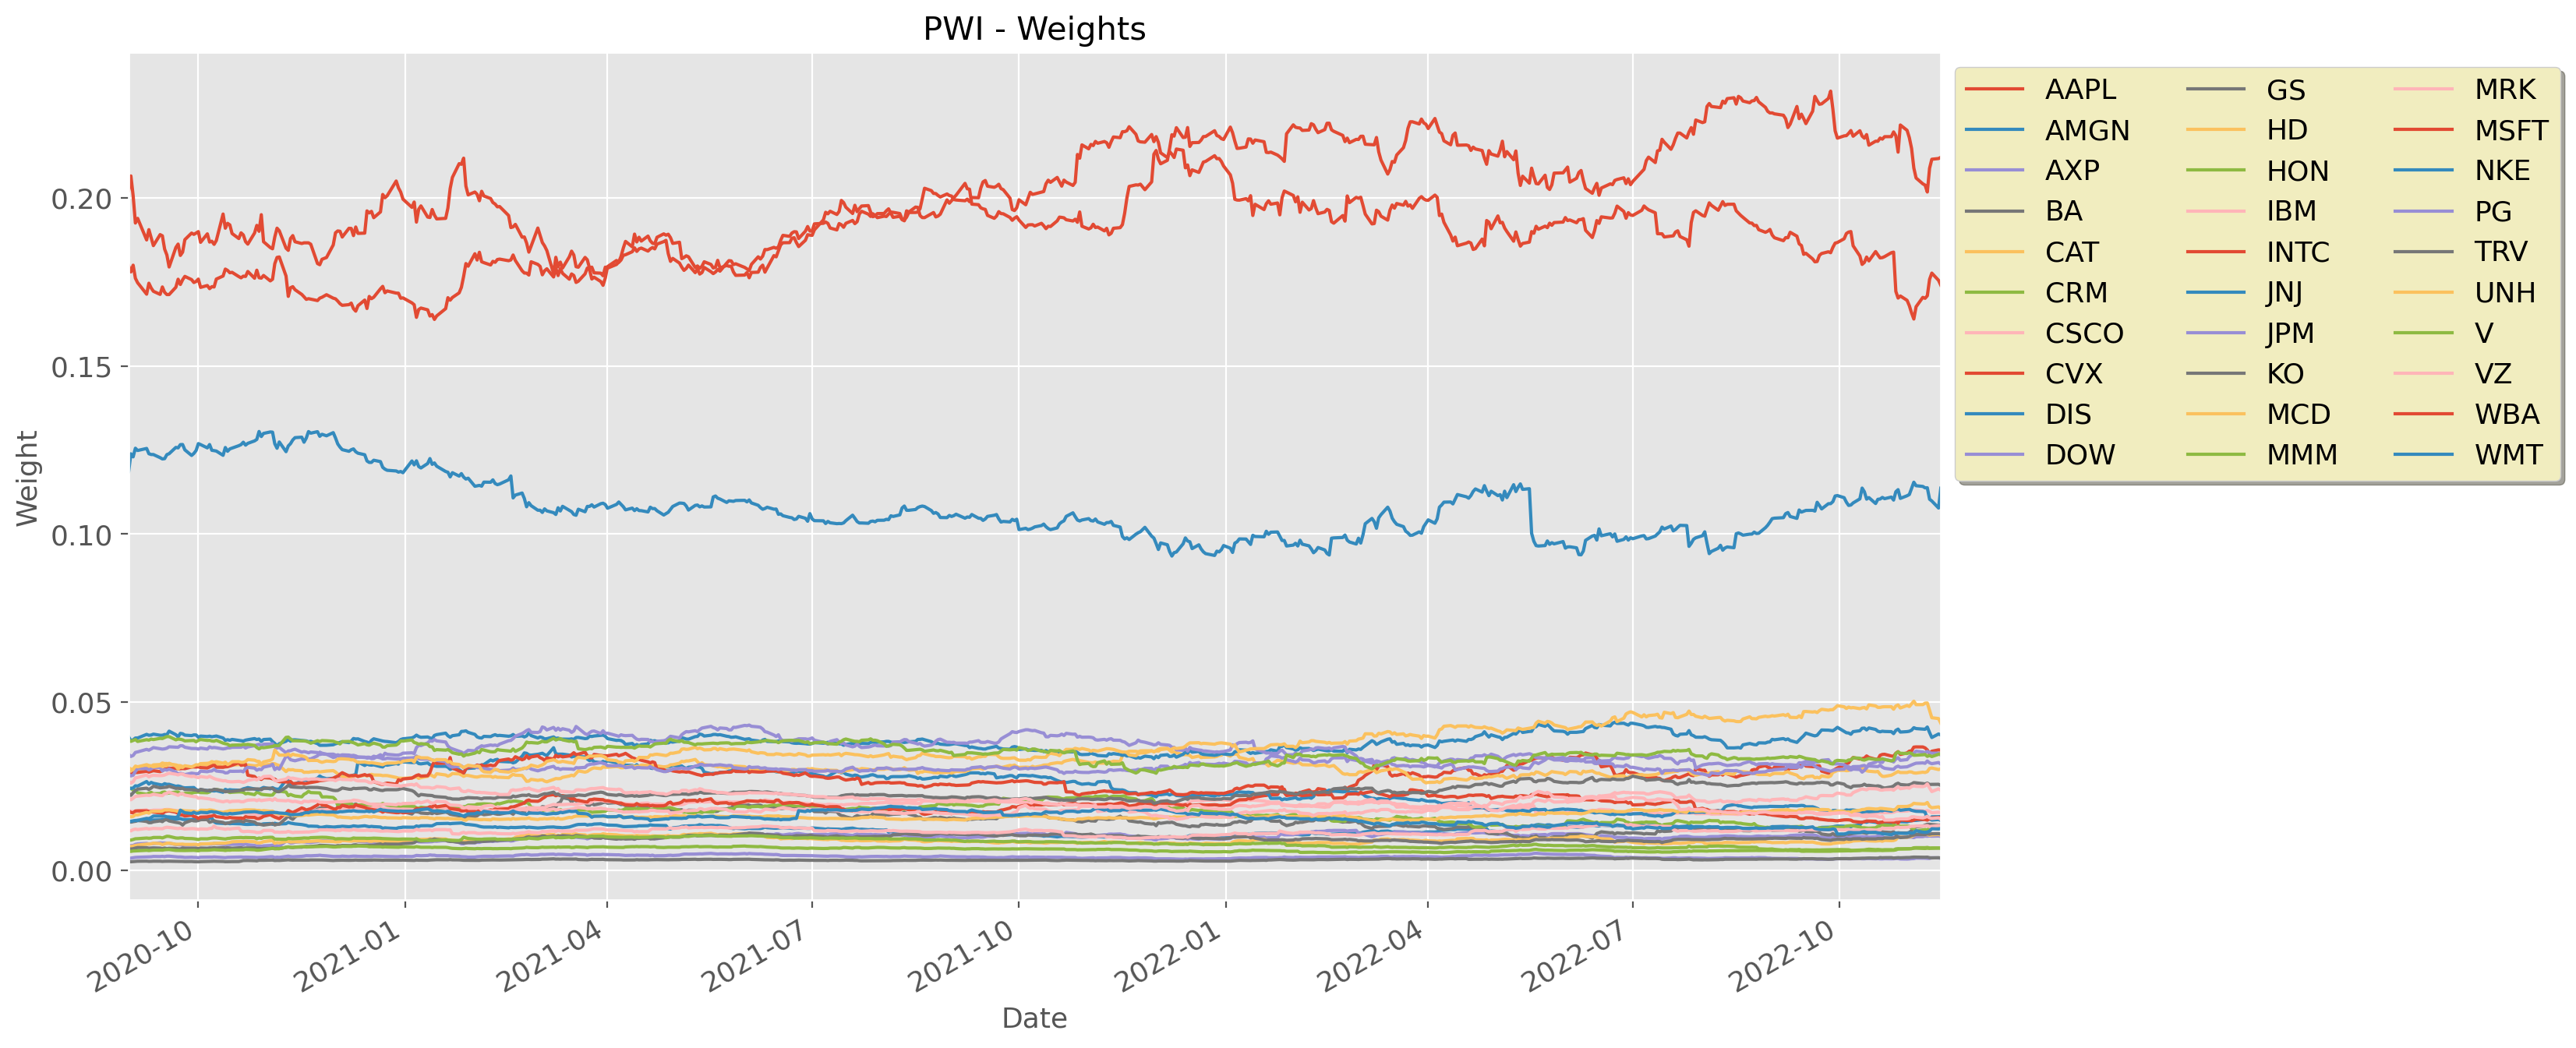

In [96]:
weights_VWI.plot(figsize = (15, 8), fontsize = 13)
plt.title("PWI - Weights", fontsize = 15)
plt.ylabel("Weight", fontsize = 13)
plt.xlabel("Date", fontsize = 13)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.legend(fontsize = 13 , bbox_to_anchor = (1.0, 1.0) , ncol = len(const)/9 , fancybox = True , shadow = True , frameon = True , facecolor =  "#F1EDBF")
plt.show()

In [97]:
returns # daily return

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,0.03983,-0.00971,0.00866,0.00163,0.02628,0.03154,-0.00450,-0.01013,0.01274,0.04765,...,0.00772,0.02637,-0.00108,-0.01163,0.00090,0.00642,-0.00186,-0.03314,0.06295,0.00758
2020-09-02,-0.02072,0.02894,0.01883,0.01557,0.02205,-0.01621,0.00928,0.00132,0.01378,0.04125,...,0.01927,0.01707,0.01686,0.02433,0.02369,0.01467,0.02316,0.01115,0.00061,0.01588
2020-09-03,-0.08006,-0.03956,0.00057,-0.03439,-0.01682,-0.04221,-0.03465,-0.01094,-0.01588,-0.01686,...,-0.06195,-0.03382,-0.01601,-0.01813,-0.01252,-0.03474,0.00132,-0.00215,-0.02126,-0.02776
2020-09-04,0.00066,0.00198,0.01158,0.01351,0.00968,-0.03890,-0.00317,-0.00425,-0.00938,0.00434,...,-0.01404,-0.00399,-0.00217,0.01058,-0.01338,-0.02058,-0.00214,-0.00539,-0.01183,-0.00563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.03319,-0.00937,-0.02889,-0.00519,-0.01858,-0.03426,-0.01569,-0.03998,-0.13163,-0.03968,...,-0.01905,-0.01760,-0.00241,-0.01487,-0.02240,-0.03890,-0.00660,-0.03656,-0.02325,-0.01951
2022-11-10,0.08897,0.00470,0.06095,0.05239,0.03064,0.10024,0.03985,0.01894,0.04277,0.04782,...,0.08227,0.08024,0.03444,0.00631,0.00649,0.06002,0.02392,0.04337,0.02072,0.03695
2022-11-11,0.01927,-0.02058,0.00090,-0.00051,0.01738,0.00915,-0.01905,0.02846,0.05030,0.06365,...,0.01700,0.06634,-0.00149,-0.00857,-0.04059,-0.00277,-0.00571,0.07197,0.00155,0.00096


In [98]:
weights_VWI # weights at the end of the day

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,0.20216,0.01470,0.00736,0.01458,0.00702,0.02409,0.01786,0.01767,0.02444,0.00350,...,0.02155,0.17978,0.01444,0.03449,0.00260,0.03012,0.03878,0.02644,NaN,0.11862
2020-09-01,0.20654,0.01430,0.00730,0.01435,0.00708,0.02441,0.01747,0.01719,0.02432,0.00360,...,0.02096,0.17799,0.01456,0.03385,0.00252,0.02962,0.03835,0.02592,NaN,0.12388
2020-09-02,0.20066,0.01460,0.00738,0.01445,0.00718,0.02383,0.01750,0.01708,0.02446,0.00372,...,0.02141,0.17999,0.01469,0.03415,0.00256,0.03008,0.03860,0.02632,NaN,0.12298
2020-09-03,0.19253,0.01463,0.00770,0.01456,0.00736,0.02380,0.01761,0.01761,0.02511,0.00381,...,0.02196,0.17610,0.01481,0.03505,0.00263,0.03098,0.03886,0.02748,NaN,0.12554
2020-09-04,0.19392,0.01475,0.00784,0.01485,0.00748,0.02303,0.01767,0.01765,0.02504,0.00386,...,0.02204,0.17477,0.01484,0.03520,0.00267,0.03076,0.03831,0.02760,NaN,0.12486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,0.20177,0.01605,0.01010,0.01367,0.01063,0.01198,0.01774,0.03578,0.01535,0.00353,...,0.02569,0.17089,0.01135,0.03249,0.00389,0.04975,0.03388,0.01602,NaN,0.11377
2022-11-10,0.20881,0.01533,0.01018,0.01367,0.01041,0.01253,0.01753,0.03465,0.01522,0.00352,...,0.02449,0.17577,0.01165,0.03195,0.00372,0.04758,0.03413,0.01559,NaN,0.11037
2022-11-11,0.21150,0.01492,0.01013,0.01358,0.01052,0.01257,0.01709,0.03541,0.01588,0.00372,...,0.02340,0.17764,0.01235,0.03170,0.00367,0.04537,0.03382,0.01540,NaN,0.10984


In [99]:
weights_VWI.shift()

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2020-09-01,0.20216,0.01470,0.00736,0.01458,0.00702,0.02409,0.01786,0.01767,0.02444,0.00350,...,0.02155,0.17978,0.01444,0.03449,0.00260,0.03012,0.03878,0.02644,NaN,0.11862
2020-09-02,0.20654,0.01430,0.00730,0.01435,0.00708,0.02441,0.01747,0.01719,0.02432,0.00360,...,0.02096,0.17799,0.01456,0.03385,0.00252,0.02962,0.03835,0.02592,NaN,0.12388
2020-09-03,0.20066,0.01460,0.00738,0.01445,0.00718,0.02383,0.01750,0.01708,0.02446,0.00372,...,0.02141,0.17999,0.01469,0.03415,0.00256,0.03008,0.03860,0.02632,NaN,0.12298
2020-09-04,0.19253,0.01463,0.00770,0.01456,0.00736,0.02380,0.01761,0.01761,0.02511,0.00381,...,0.02196,0.17610,0.01481,0.03505,0.00263,0.03098,0.03886,0.02748,NaN,0.12554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,0.20381,0.01582,0.01015,0.01342,0.01058,0.01212,0.01760,0.03640,0.01727,0.00359,...,0.02507,0.17013,0.01128,0.03181,0.00386,0.04970,0.03442,0.01575,NaN,0.11376
2022-11-10,0.20177,0.01605,0.01010,0.01367,0.01063,0.01198,0.01774,0.03578,0.01535,0.00353,...,0.02569,0.17089,0.01135,0.03249,0.00389,0.04975,0.03388,0.01602,NaN,0.11377
2022-11-11,0.20881,0.01533,0.01018,0.01367,0.01041,0.01253,0.01753,0.03465,0.01522,0.00352,...,0.02449,0.17577,0.01165,0.03195,0.00372,0.04758,0.03413,0.01559,NaN,0.11037


In [102]:
returns[const].shape , weights_VWI.shift().shape

((558, 30), (558, 30))

In [109]:
returns[const].mul(weights_VWI.shift())

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,0.00805,-0.00014,0.00006,0.00002,0.00018,0.00076,-0.00008,-0.00018,0.00031,0.00017,...,-0.00021,0.00139,0.00038,-0.00004,-0.00003,0.00003,0.00025,-0.00005,NaN,0.00747
2020-09-02,-0.00428,0.00041,0.00014,0.00022,0.00016,-0.00040,0.00016,0.00002,0.00034,0.00015,...,0.00062,0.00343,0.00025,0.00057,0.00006,0.00070,0.00056,0.00060,NaN,0.00008
2020-09-03,-0.01607,-0.00058,0.00000,-0.00050,-0.00012,-0.00101,-0.00061,-0.00019,-0.00039,-0.00006,...,-0.00035,-0.01115,-0.00050,-0.00055,-0.00005,-0.00038,-0.00134,0.00003,NaN,-0.00261
2020-09-04,0.00013,0.00003,0.00009,0.00020,0.00007,-0.00093,-0.00006,-0.00007,-0.00024,0.00002,...,-0.00006,-0.00247,-0.00006,-0.00008,0.00003,-0.00041,-0.00080,-0.00006,NaN,-0.00149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.00676,-0.00015,-0.00029,-0.00007,-0.00020,-0.00042,-0.00028,-0.00146,-0.00227,-0.00014,...,0.00002,-0.00324,-0.00020,-0.00008,-0.00006,-0.00111,-0.00134,-0.00010,NaN,-0.00264
2022-11-10,0.01795,0.00008,0.00062,0.00072,0.00033,0.00120,0.00071,0.00068,0.00066,0.00017,...,0.00008,0.01406,0.00091,0.00112,0.00002,0.00032,0.00203,0.00038,NaN,0.00236
2022-11-11,0.00402,-0.00032,0.00001,-0.00001,0.00018,0.00011,-0.00033,0.00099,0.00077,0.00022,...,-0.00094,0.00299,0.00077,-0.00005,-0.00003,-0.00193,-0.00009,-0.00009,NaN,0.00017


In [110]:
returns[const].mul(weights_VWI.shift()).sum(axis = "columns") 

Date
2020-08-31          0
2020-09-01    0.01780
2020-09-02    0.00796
2020-09-03   -0.04121
2020-09-04   -0.00652
               ...   
2022-11-09   -0.02340
2022-11-10    0.05223
2022-11-11    0.00631
2022-11-14   -0.01053
2022-11-15    0.01017
Length: 558, dtype: object

In [111]:
mcwr = returns[const].mul(weights_VWI.shift()).sum(axis = "columns") 
mcwr # simple returns vwi

Date
2020-08-31          0
2020-09-01    0.01780
2020-09-02    0.00796
2020-09-03   -0.04121
2020-09-04   -0.00652
               ...   
2022-11-09   -0.02340
2022-11-10    0.05223
2022-11-11    0.00631
2022-11-14   -0.01053
2022-11-15    0.01017
Length: 558, dtype: object

In [112]:
vwi = mcwr.add(1).cumprod().mul(100)
vwi

Date
2020-08-31         100
2020-09-01   101.77996
2020-09-02   102.58995
2020-09-03    98.36197
2020-09-04    97.72076
                ...   
2022-11-09   104.72378
2022-11-10   110.19383
2022-11-11   110.88875
2022-11-14   109.72100
2022-11-15   110.83633
Length: 558, dtype: object

In [113]:
vwi.name = "vwi"
vwi

Date
2020-08-31         100
2020-09-01   101.77996
2020-09-02   102.58995
2020-09-03    98.36197
2020-09-04    97.72076
                ...   
2022-11-09   104.72378
2022-11-10   110.19383
2022-11-11   110.88875
2022-11-14   109.72100
2022-11-15   110.83633
Name: vwi, Length: 558, dtype: object

## Analysis and Comparison (Part 1)

In [115]:
indices = pd.concat([vwi, pwi, ewi], axis = 1).iloc[:-1]
indices

,vwi,pwi,ewi
Date,,,
2020-08-31,100,100.00000,100.00000
2020-09-01,101.77996,100.76083,100.64983
2020-09-02,102.58995,102.35662,102.43863
2020-09-03,98.36197,99.51457,99.91993
2020-09-04,97.72076,98.95506,99.62227
...,...,...,...
2022-11-08,107.23290,116.69279,115.69004
2022-11-09,104.72378,114.41641,113.09603
2022-11-10,110.19383,118.64424,117.78518


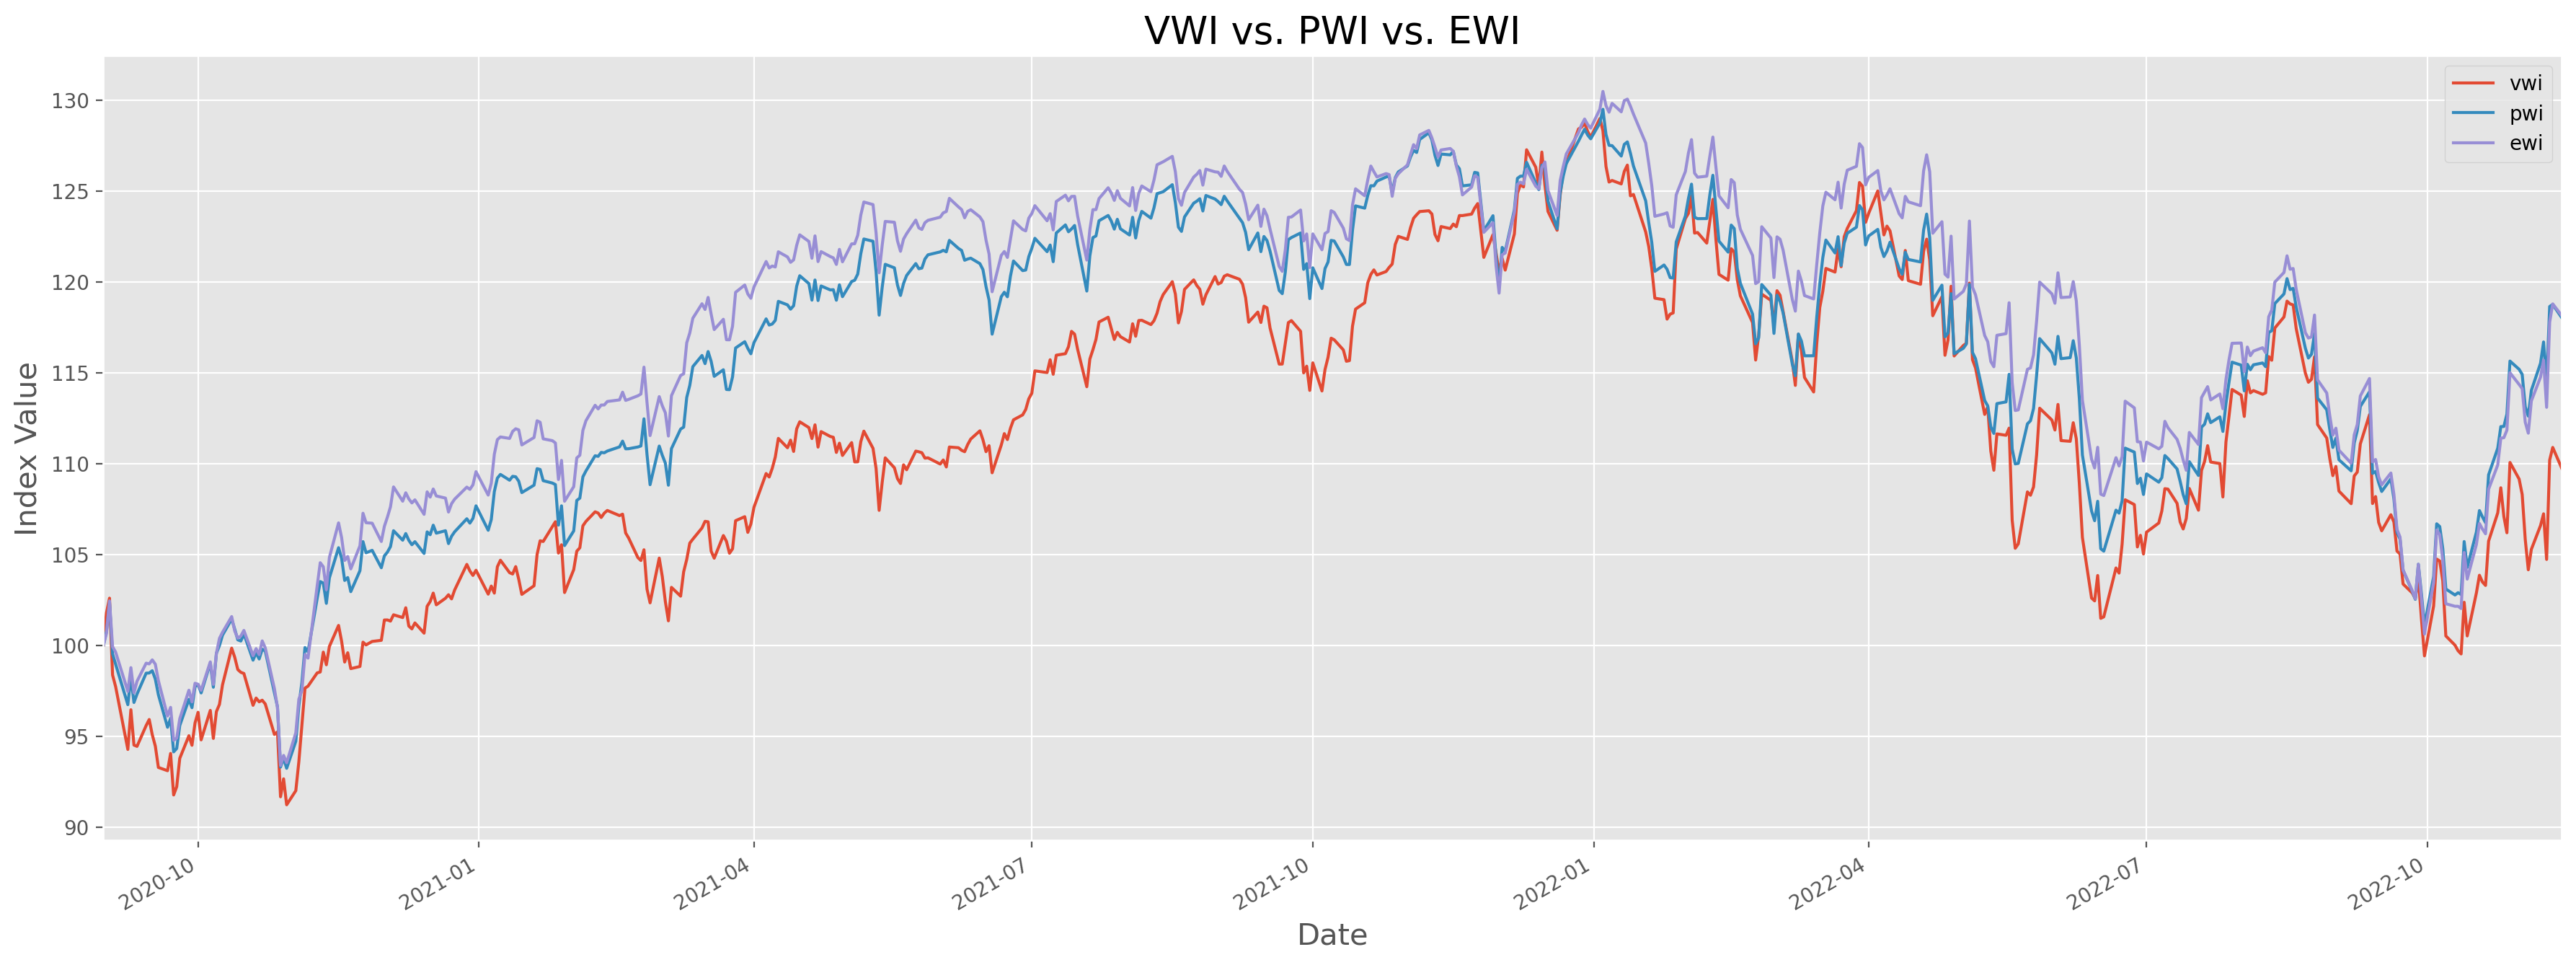

In [121]:
indices.plot(figsize = (22, 8))
plt.title("VWI vs. PWI vs. EWI", fontsize = 19)
plt.xlabel("Date", fontsize = 15)
plt.ylabel("Index Value", fontsize = 15)
plt.autoscale(enable = True, axis = "x", tight = True)
plt.show()

__Keep in mind:__ While VWI and PWI are (mostly) __self-rebalancing__, EWI requires/assumes __daily rebalancing__! -> __Trading Costs__! 
So we should focus on PWI

## Analysis and Comparison (Part 2)

In [122]:
indices

,vwi,pwi,ewi
Date,,,
2020-08-31,100,100.00000,100.00000
2020-09-01,101.77996,100.76083,100.64983
2020-09-02,102.58995,102.35662,102.43863
2020-09-03,98.36197,99.51457,99.91993
2020-09-04,97.72076,98.95506,99.62227
...,...,...,...
2022-11-08,107.23290,116.69279,115.69004
2022-11-09,104.72378,114.41641,113.09603
2022-11-10,110.19383,118.64424,117.78518


In [123]:
close

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,129.03999,253.32001,101.59000,171.82001,142.31000,272.64999,42.22000,83.93000,131.87000,45.12000,...,225.53000,111.89000,138.33000,116.04000,312.54999,211.99001,59.27000,38.02000,138.85001,28430.05078
2020-09-01,134.17999,250.86000,102.47000,172.10001,146.05000,281.25000,42.03000,83.08000,133.55000,47.27000,...,227.27000,114.84000,138.17999,114.69000,312.82999,213.35001,59.16000,36.76000,147.59000,28645.66016
2020-09-02,131.39999,258.12000,104.40000,174.78000,149.27000,276.69000,42.42000,83.19000,135.39000,49.22000,...,231.64999,116.80000,140.50999,117.48000,320.23999,216.48000,60.53000,37.17000,147.67999,29100.50000
2020-09-03,120.88000,247.91000,104.46000,168.77000,146.75999,265.01001,40.95000,82.28000,133.24001,48.39000,...,217.30000,112.85000,138.25999,115.35000,316.23001,208.96001,60.61000,37.09000,144.53999,28292.73047
2020-09-04,120.96000,248.39999,105.67000,171.05000,148.17999,254.70000,40.82000,81.93000,131.99001,48.60000,...,214.25000,112.40000,137.96001,116.57000,312.00000,204.66000,60.48000,36.89000,142.83000,28133.31055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,134.87000,289.64999,145.86000,168.74001,225.53999,142.06000,43.91000,177.92999,86.75000,47.68000,...,224.50999,92.10000,136.48000,182.14999,540.65997,193.92999,37.62000,36.89000,139.47000,32513.93945
2022-11-10,146.87000,291.01001,154.75000,177.58000,232.45000,156.30000,45.66000,181.30000,90.46000,49.96000,...,242.98000,99.49000,141.17999,183.30000,544.16998,205.57001,38.52000,38.49000,142.36000,33715.37109
2022-11-11,149.70000,285.01999,154.89000,177.49001,236.49001,157.73000,44.79000,186.46001,95.01000,53.14000,...,247.11000,106.09000,140.97000,181.73000,522.08002,205.00000,38.30000,41.26000,142.58000,33747.85938


In [124]:
prices_m = pd.concat([close[const], indices], axis = 1)
prices_m

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,PG,TRV,UNH,V,VZ,WBA,WMT,vwi,pwi,ewi
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,129.03999,253.32001,101.59000,171.82001,142.31000,272.64999,42.22000,83.93000,131.87000,45.12000,...,138.33000,116.04000,312.54999,211.99001,59.27000,38.02000,138.85001,100,100.00000,100.00000
2020-09-01,134.17999,250.86000,102.47000,172.10001,146.05000,281.25000,42.03000,83.08000,133.55000,47.27000,...,138.17999,114.69000,312.82999,213.35001,59.16000,36.76000,147.59000,101.77996,100.76083,100.64983
2020-09-02,131.39999,258.12000,104.40000,174.78000,149.27000,276.69000,42.42000,83.19000,135.39000,49.22000,...,140.50999,117.48000,320.23999,216.48000,60.53000,37.17000,147.67999,102.58995,102.35662,102.43863
2020-09-03,120.88000,247.91000,104.46000,168.77000,146.75999,265.01001,40.95000,82.28000,133.24001,48.39000,...,138.25999,115.35000,316.23001,208.96001,60.61000,37.09000,144.53999,98.36197,99.51457,99.91993
2020-09-04,120.96000,248.39999,105.67000,171.05000,148.17999,254.70000,40.82000,81.93000,131.99001,48.60000,...,137.96001,116.57000,312.00000,204.66000,60.48000,36.89000,142.83000,97.72076,98.95506,99.62227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,134.87000,289.64999,145.86000,168.74001,225.53999,142.06000,43.91000,177.92999,86.75000,47.68000,...,136.48000,182.14999,540.65997,193.92999,37.62000,36.89000,139.47000,104.72378,114.41641,113.09603
2022-11-10,146.87000,291.01001,154.75000,177.58000,232.45000,156.30000,45.66000,181.30000,90.46000,49.96000,...,141.17999,183.30000,544.16998,205.57001,38.52000,38.49000,142.36000,110.19383,118.64424,117.78518
2022-11-11,149.70000,285.01999,154.89000,177.49001,236.49001,157.73000,44.79000,186.46001,95.01000,53.14000,...,140.97000,181.73000,522.08002,205.00000,38.30000,41.26000,142.58000,110.88875,118.75858,118.78860


In [146]:
returns_m = prices_m.pct_change().dropna() # simple returns
returns_m

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,PG,TRV,UNH,V,VZ,WBA,WMT,vwi,pwi,ewi
Date,,,,,,,,,,,,,,,,,,,,,
2020-09-01,0.03983,-0.00971,0.00866,0.00163,0.02628,0.03154,-0.00450,-0.01013,0.01274,0.04765,...,-0.00108,-0.01163,0.00090,0.00642,-0.00186,-0.03314,0.06295,0.01780,0.00761,0.00650
2020-09-02,-0.02072,0.02894,0.01883,0.01557,0.02205,-0.01621,0.00928,0.00132,0.01378,0.04125,...,0.01686,0.02433,0.02369,0.01467,0.02316,0.01115,0.00061,0.00796,0.01584,0.01777
2020-09-03,-0.08006,-0.03956,0.00057,-0.03439,-0.01682,-0.04221,-0.03465,-0.01094,-0.01588,-0.01686,...,-0.01601,-0.01813,-0.01252,-0.03474,0.00132,-0.00215,-0.02126,-0.04121,-0.02777,-0.02459
2020-09-04,0.00066,0.00198,0.01158,0.01351,0.00968,-0.03890,-0.00317,-0.00425,-0.00938,0.00434,...,-0.00217,0.01058,-0.01338,-0.02058,-0.00214,-0.00539,-0.01183,-0.00652,-0.00562,-0.00298
2020-09-08,-0.06729,-0.02907,-0.01893,-0.05829,0.00229,-0.05273,-0.02009,-0.03613,0.01674,-0.01379,...,-0.01464,-0.02428,-0.01522,-0.02218,-0.00860,-0.02142,-0.03067,-0.03536,-0.02250,-0.02170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.03319,-0.00937,-0.02889,-0.00519,-0.01858,-0.03426,-0.01569,-0.03998,-0.13163,-0.03968,...,-0.00241,-0.01487,-0.02240,-0.03890,-0.00660,-0.03656,-0.02325,-0.02340,-0.01951,-0.02242
2022-11-10,0.08897,0.00470,0.06095,0.05239,0.03064,0.10024,0.03985,0.01894,0.04277,0.04782,...,0.03444,0.00631,0.00649,0.06002,0.02392,0.04337,0.02072,0.05223,0.03695,0.04146
2022-11-11,0.01927,-0.02058,0.00090,-0.00051,0.01738,0.00915,-0.01905,0.02846,0.05030,0.06365,...,-0.00149,-0.00857,-0.04059,-0.00277,-0.00571,0.07197,0.00155,0.00631,0.00096,0.00852


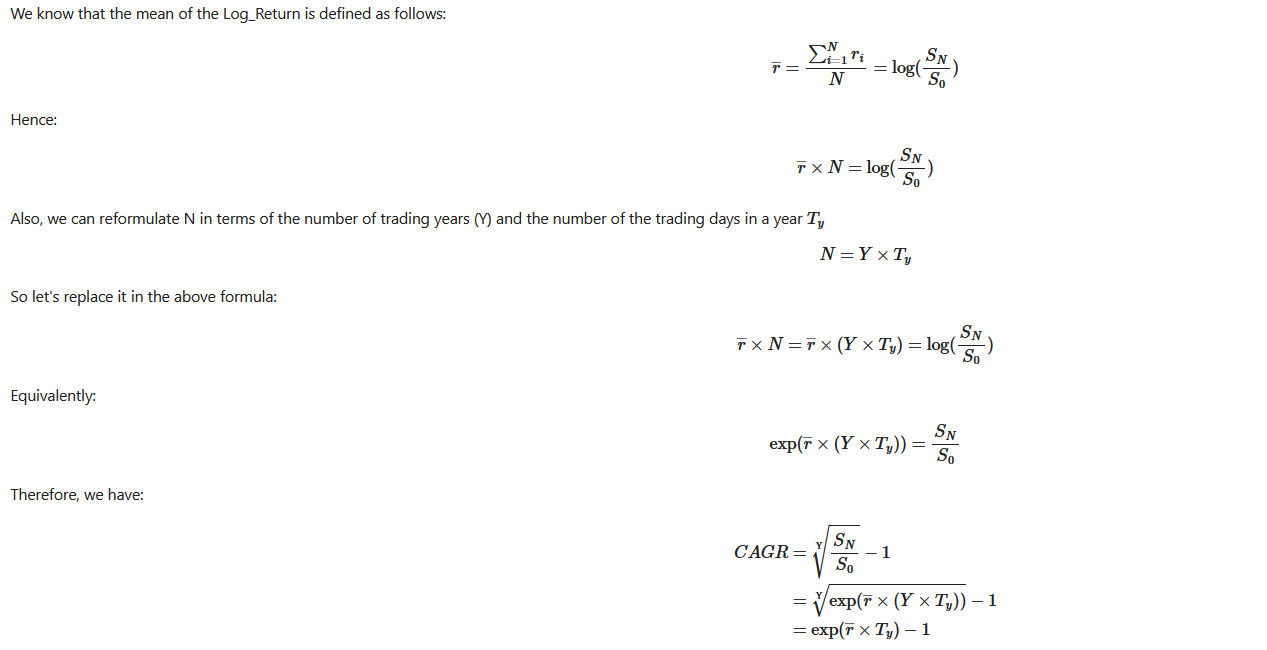

In [ ]:
def ann_risk_return(returns_df): # assumes simple returns as input
    summary = pd.DataFrame(index = returns_df.columns)
    summary["Ann. Risk"] = np.sqrt(returns_df.var() * 252)
    log_returns = np.log(returns_df + 1)
    summary["CAGR"] = np.exp(log_returns.mean() * 252) - 1
    return summary

In [127]:
summary = ann_risk_return(returns_m)
summary

,ann. Risk,CAGR
AAPL,0.32400,0.07060
AMGN,0.22337,0.05241
AXP,0.35201,0.20670
BA,0.43875,0.00924
CAT,0.30686,0.25375
CRM,0.38287,-0.20969
CSCO,0.24740,0.02824
CVX,0.31550,0.44049
DIS,0.32803,-0.13580
DOW,0.31283,0.06259


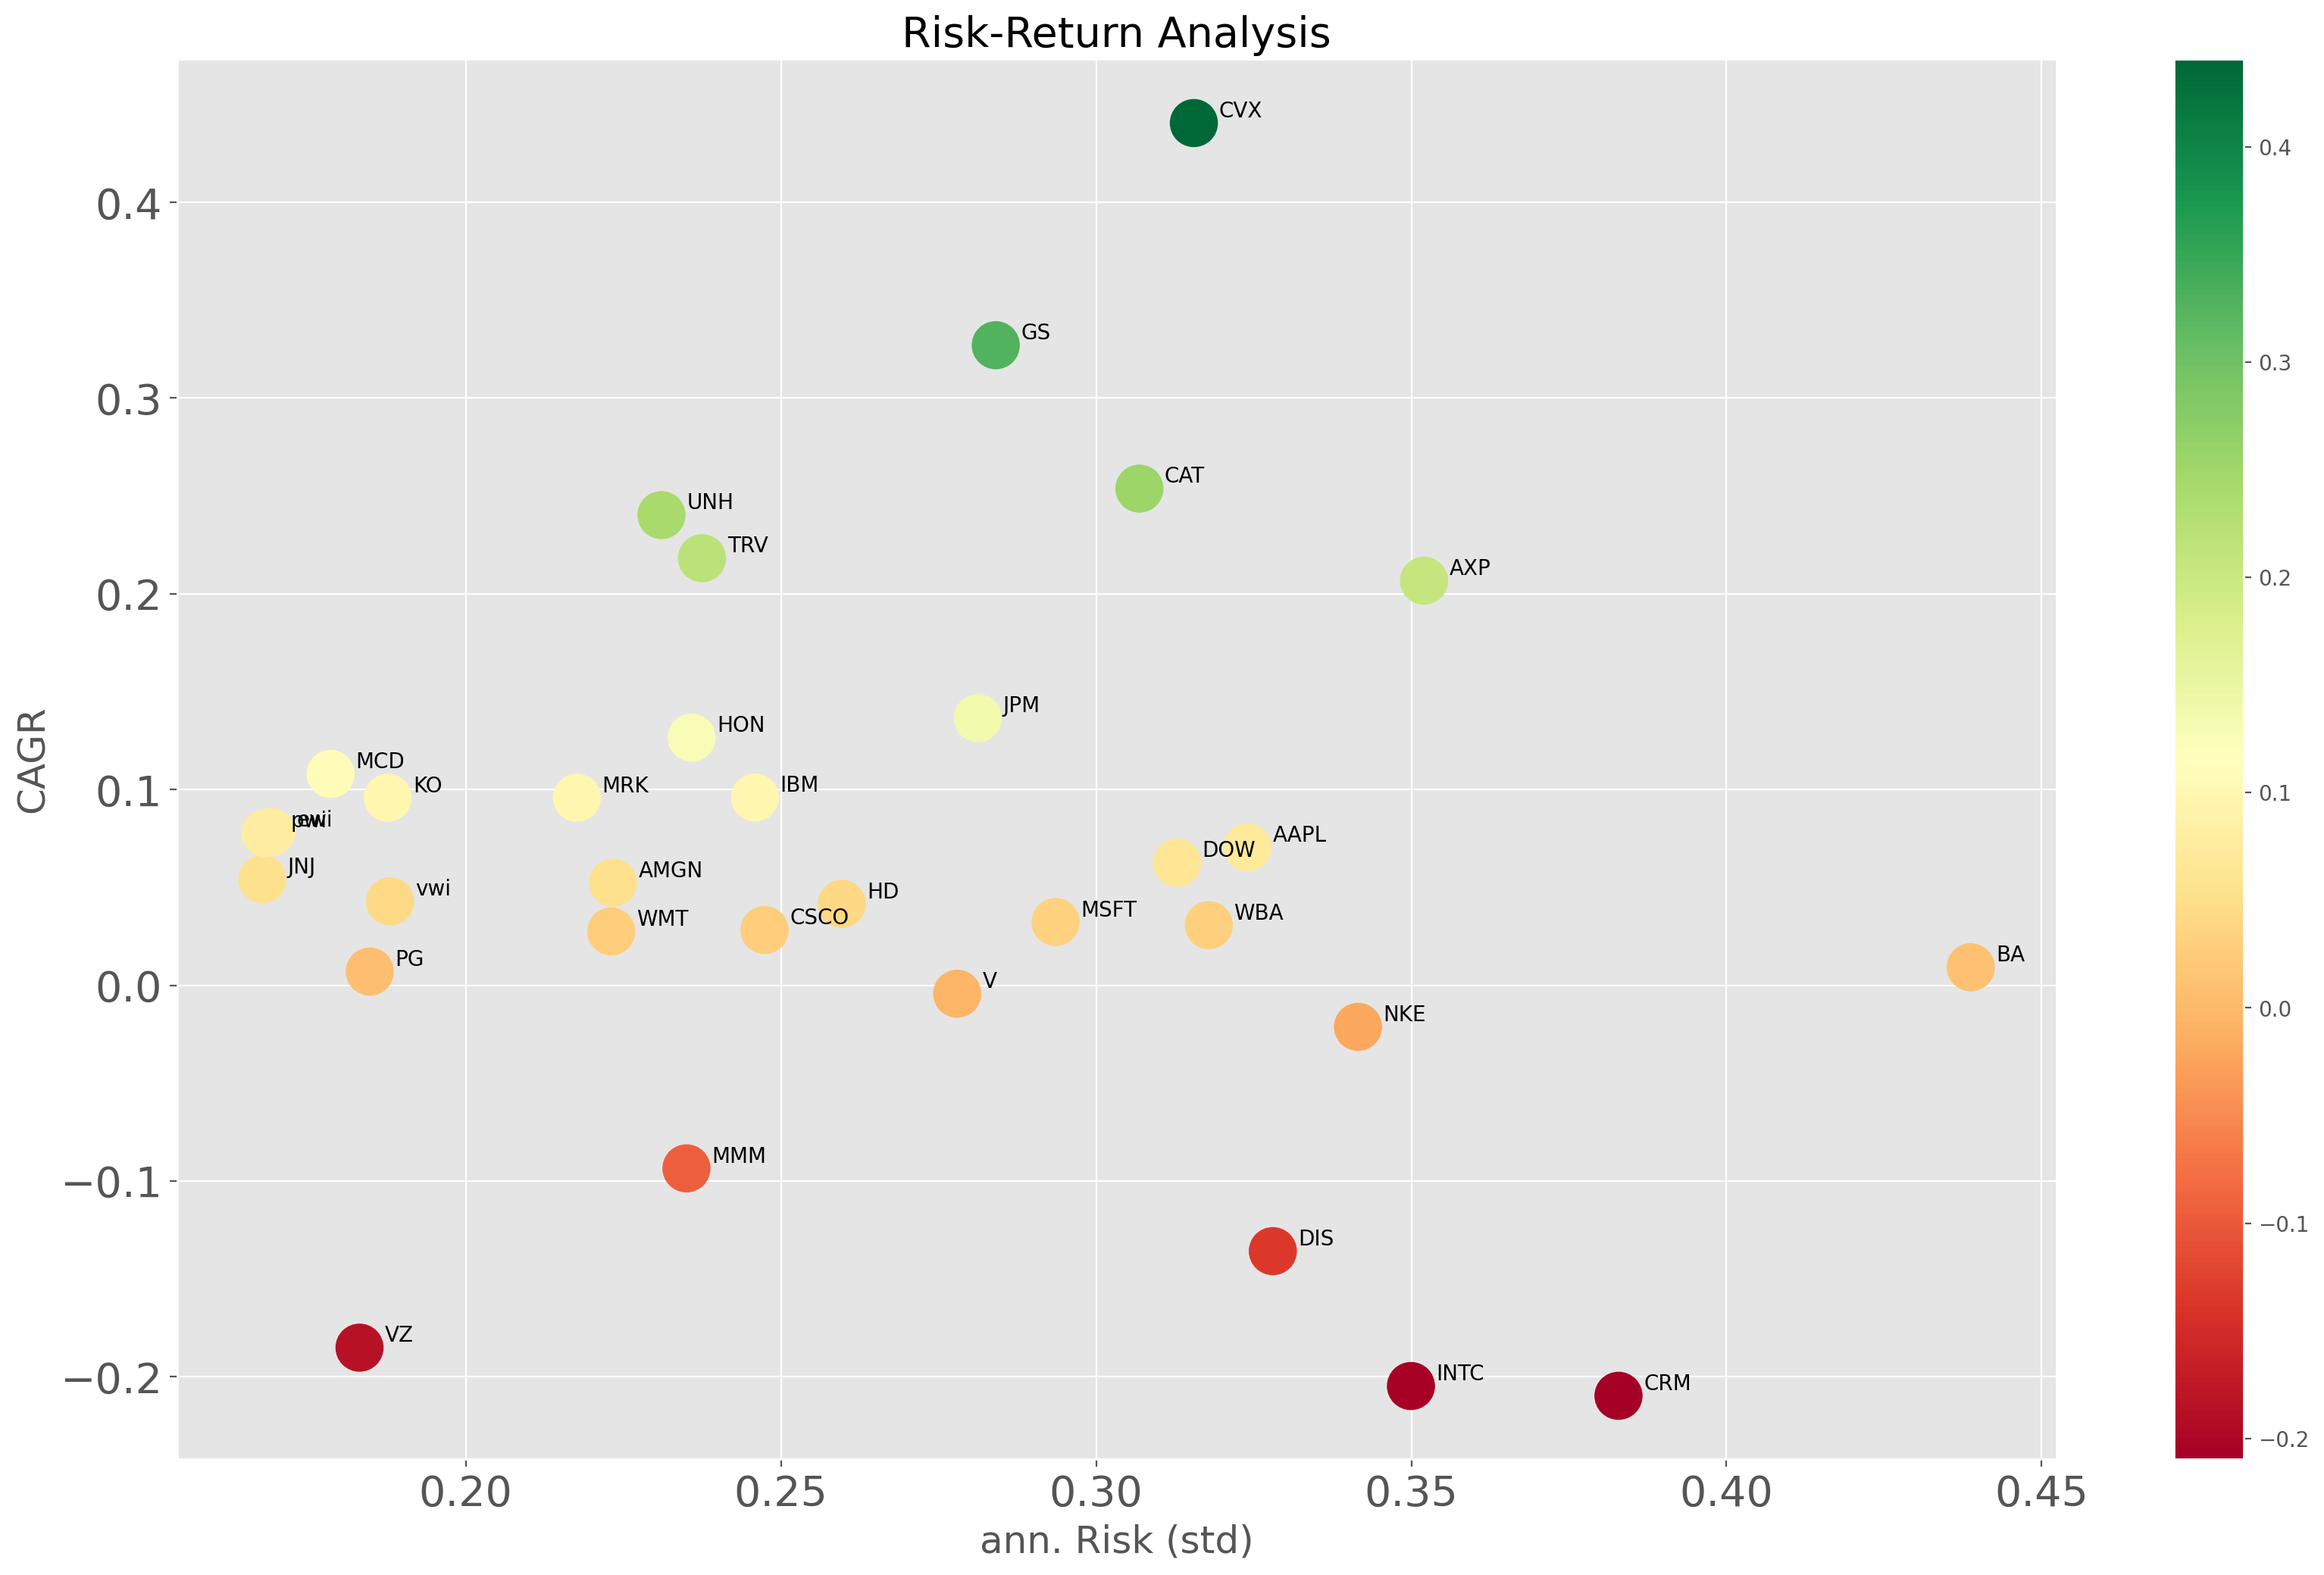

In [160]:
summary.plot(kind = "scatter", 
             x = "ann. Risk", 
             y = "CAGR", 
             figsize = (20,12), 
             s = 500, 
             fontsize = 20 , 
             cmap = "RdYlGn" , 
             c = summary["CAGR"])
for i in summary.index:
    plt.annotate(i, 
                 xy=(summary.loc[i, "ann. Risk"]+0.004, summary.loc[i, "CAGR"]+0.003), 
                 size = 10)
plt.xlabel("ann. Risk (std)", fontsize = 18)
plt.ylabel("CAGR", fontsize = 18)
plt.title("Risk-Return Analysis", fontsize = 20)

plt.show()

- All three Indexes benefit from the __Portfolio Diversification Effect__!
- __Concentrated Positions__ negatively affect __VWI__
- PWI and EWI are closely together (before Trading Costs)
- But: EWI requires __daily rebalancing__! (Trading Costs)

## The DJIA Total Return Index

In [140]:
weights_PWI # based on Close Prices

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,0.02993,0.05875,0.02356,0.03985,0.03301,0.06324,0.00979,0.01947,0.03058,0.01046,...,0.01887,0.05231,0.02595,0.03208,0.02691,0.07249,0.04917,0.01375,0.00882,0.03220
2020-09-01,0.03089,0.05774,0.02359,0.03961,0.03362,0.06474,0.00967,0.01912,0.03074,0.01088,...,0.01854,0.05231,0.02643,0.03181,0.02640,0.07201,0.04911,0.01362,0.00846,0.03397
2020-09-02,0.02977,0.05849,0.02366,0.03960,0.03382,0.06269,0.00961,0.01885,0.03068,0.01115,...,0.01880,0.05249,0.02647,0.03184,0.02662,0.07256,0.04905,0.01372,0.00842,0.03346
2020-09-03,0.02817,0.05778,0.02435,0.03933,0.03420,0.06176,0.00954,0.01918,0.03105,0.01128,...,0.01901,0.05064,0.02630,0.03222,0.02688,0.07370,0.04870,0.01413,0.00864,0.03369
2020-09-04,0.02835,0.05822,0.02477,0.04009,0.03473,0.05970,0.00957,0.01920,0.03094,0.01139,...,0.01906,0.05022,0.02634,0.03233,0.02732,0.07313,0.04797,0.01418,0.00865,0.03348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,0.02734,0.05871,0.02957,0.03420,0.04572,0.02880,0.00890,0.03607,0.01758,0.00967,...,0.02059,0.04551,0.01867,0.02767,0.03692,0.10959,0.03931,0.00763,0.00748,0.02827
2022-11-10,0.02871,0.05689,0.03025,0.03471,0.04544,0.03055,0.00893,0.03544,0.01768,0.00977,...,0.01992,0.04750,0.01945,0.02760,0.03583,0.10638,0.04019,0.00753,0.00752,0.02783
2022-11-11,0.02924,0.05566,0.03025,0.03466,0.04619,0.03080,0.00875,0.03641,0.01855,0.01038,...,0.01913,0.04826,0.02072,0.02753,0.03549,0.10196,0.04004,0.00748,0.00806,0.02785


In [144]:
total_returns = df["Adj Close"].pct_change() # Adj Close Prices!
total_returns

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT,^DJI
Date,,,,,,,,,,,,,,,,,,,,,
2020-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,0.03983,-0.00971,0.00866,0.00163,0.02628,0.03154,-0.00450,-0.01013,0.01274,0.04765,...,0.00772,0.02637,-0.00108,-0.01163,0.00090,0.00642,-0.00186,-0.03314,0.06295,0.00758
2020-09-02,-0.02072,0.02894,0.01883,0.01557,0.02205,-0.01621,0.00928,0.00132,0.01378,0.04125,...,0.01927,0.01707,0.01686,0.02433,0.02369,0.01467,0.02316,0.01115,0.00061,0.01588
2020-09-03,-0.08006,-0.03956,0.00057,-0.03439,-0.01682,-0.04221,-0.03465,-0.01094,-0.01588,-0.01686,...,-0.06195,-0.03382,-0.01601,-0.01813,-0.01252,-0.03474,0.00132,-0.00215,-0.02126,-0.02776
2020-09-04,0.00066,0.00198,0.01158,0.01351,0.00968,-0.03890,-0.00317,-0.00425,-0.00938,0.00434,...,-0.01404,-0.00399,-0.00217,0.01058,-0.01338,-0.02058,-0.00214,-0.00539,-0.01183,-0.00563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.03319,-0.00937,-0.02889,-0.00519,-0.01858,-0.03426,-0.01569,-0.03998,-0.13163,-0.03968,...,-0.01905,-0.01760,-0.00241,-0.01487,-0.02240,-0.03676,-0.00660,-0.03656,-0.02325,-0.01951
2022-11-10,0.08897,0.00470,0.06095,0.05239,0.03064,0.10024,0.03985,0.01894,0.04277,0.04782,...,0.08227,0.08024,0.03444,0.00631,0.00649,0.06002,0.02392,0.04337,0.02072,0.03695
2022-11-11,0.01927,-0.02058,0.00090,-0.00051,0.01738,0.00915,-0.01905,0.02846,0.05030,0.06365,...,0.01700,0.06634,-0.00149,-0.00857,-0.04059,-0.00277,-0.00571,0.07197,0.00155,0.00096


In [161]:
returns_tr = total_returns[const].mul(weights_PWI.shift()).sum(axis = "columns")
returns_tr # simple returns DJI Total Return Index

Date
2020-08-31    0.00000
2020-09-01    0.00761
2020-09-02    0.01619
2020-09-03   -0.02777
2020-09-04   -0.00562
               ...   
2022-11-09   -0.01889
2022-11-10    0.03695
2022-11-11    0.00096
2022-11-14   -0.00616
2022-11-15    0.00168
Length: 558, dtype: float64

In [162]:
dji_tr = returns_tr.add(1).cumprod().mul(100)
dji_tr

Date
2020-08-31   100.00000
2020-09-01   100.76083
2020-09-02   102.39175
2020-09-03    99.54872
2020-09-04    98.98903
                ...   
2022-11-09   119.29817
2022-11-10   123.70638
2022-11-11   123.82560
2022-11-14   123.06234
2022-11-15   123.26863
Length: 558, dtype: float64

In [163]:
returns_m["DJI_TR"] = returns_tr
returns_m

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,...,TRV,UNH,V,VZ,WBA,WMT,vwi,pwi,ewi,DJI_TR
Date,,,,,,,,,,,,,,,,,,,,,
2020-09-01,0.03983,-0.00971,0.00866,0.00163,0.02628,0.03154,-0.00450,-0.01013,0.01274,0.04765,...,-0.01163,0.00090,0.00642,-0.00186,-0.03314,0.06295,0.01780,0.00761,0.00650,0.00761
2020-09-02,-0.02072,0.02894,0.01883,0.01557,0.02205,-0.01621,0.00928,0.00132,0.01378,0.04125,...,0.02433,0.02369,0.01467,0.02316,0.01115,0.00061,0.00796,0.01584,0.01777,0.01619
2020-09-03,-0.08006,-0.03956,0.00057,-0.03439,-0.01682,-0.04221,-0.03465,-0.01094,-0.01588,-0.01686,...,-0.01813,-0.01252,-0.03474,0.00132,-0.00215,-0.02126,-0.04121,-0.02777,-0.02459,-0.02777
2020-09-04,0.00066,0.00198,0.01158,0.01351,0.00968,-0.03890,-0.00317,-0.00425,-0.00938,0.00434,...,0.01058,-0.01338,-0.02058,-0.00214,-0.00539,-0.01183,-0.00652,-0.00562,-0.00298,-0.00562
2020-09-08,-0.06729,-0.02907,-0.01893,-0.05829,0.00229,-0.05273,-0.02009,-0.03613,0.01674,-0.01379,...,-0.02428,-0.01522,-0.02218,-0.00860,-0.02142,-0.03067,-0.03536,-0.02250,-0.02170,-0.02250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-09,-0.03319,-0.00937,-0.02889,-0.00519,-0.01858,-0.03426,-0.01569,-0.03998,-0.13163,-0.03968,...,-0.01487,-0.02240,-0.03890,-0.00660,-0.03656,-0.02325,-0.02340,-0.01951,-0.02242,-0.01889
2022-11-10,0.08897,0.00470,0.06095,0.05239,0.03064,0.10024,0.03985,0.01894,0.04277,0.04782,...,0.00631,0.00649,0.06002,0.02392,0.04337,0.02072,0.05223,0.03695,0.04146,0.03695
2022-11-11,0.01927,-0.02058,0.00090,-0.00051,0.01738,0.00915,-0.01905,0.02846,0.05030,0.06365,...,-0.00857,-0.04059,-0.00277,-0.00571,0.07197,0.00155,0.00631,0.00096,0.00852,0.00096


In [168]:
summary_TR = ann_risk_return(returns_m)
summary_TR

,ann. Risk,CAGR
AAPL,0.32400,0.07060
AMGN,0.22337,0.05241
AXP,0.35201,0.20670
BA,0.43875,0.00924
CAT,0.30686,0.25375
CRM,0.38287,-0.20969
CSCO,0.24740,0.02824
CVX,0.31550,0.44049
DIS,0.32803,-0.13580
DOW,0.31283,0.06259


In [ ]:
summary.plot(kind = "scatter", x = "ann. Risk", y = "CAGR", figsize = (15,12), s = 50, fontsize = 15)
for i in summary.index:
    plt.annotate(i, xy=(summary.loc[i, "ann. Risk"]+0.005, summary.loc[i, "CAGR"]+0.005), size = 10)
plt.grid()
plt.xlabel("ann. Risk (std)", fontsize = 15)
plt.ylabel("CAGR", fontsize = 15)
plt.title("Risk-Return Analysis", fontsize = 20)
plt.show()

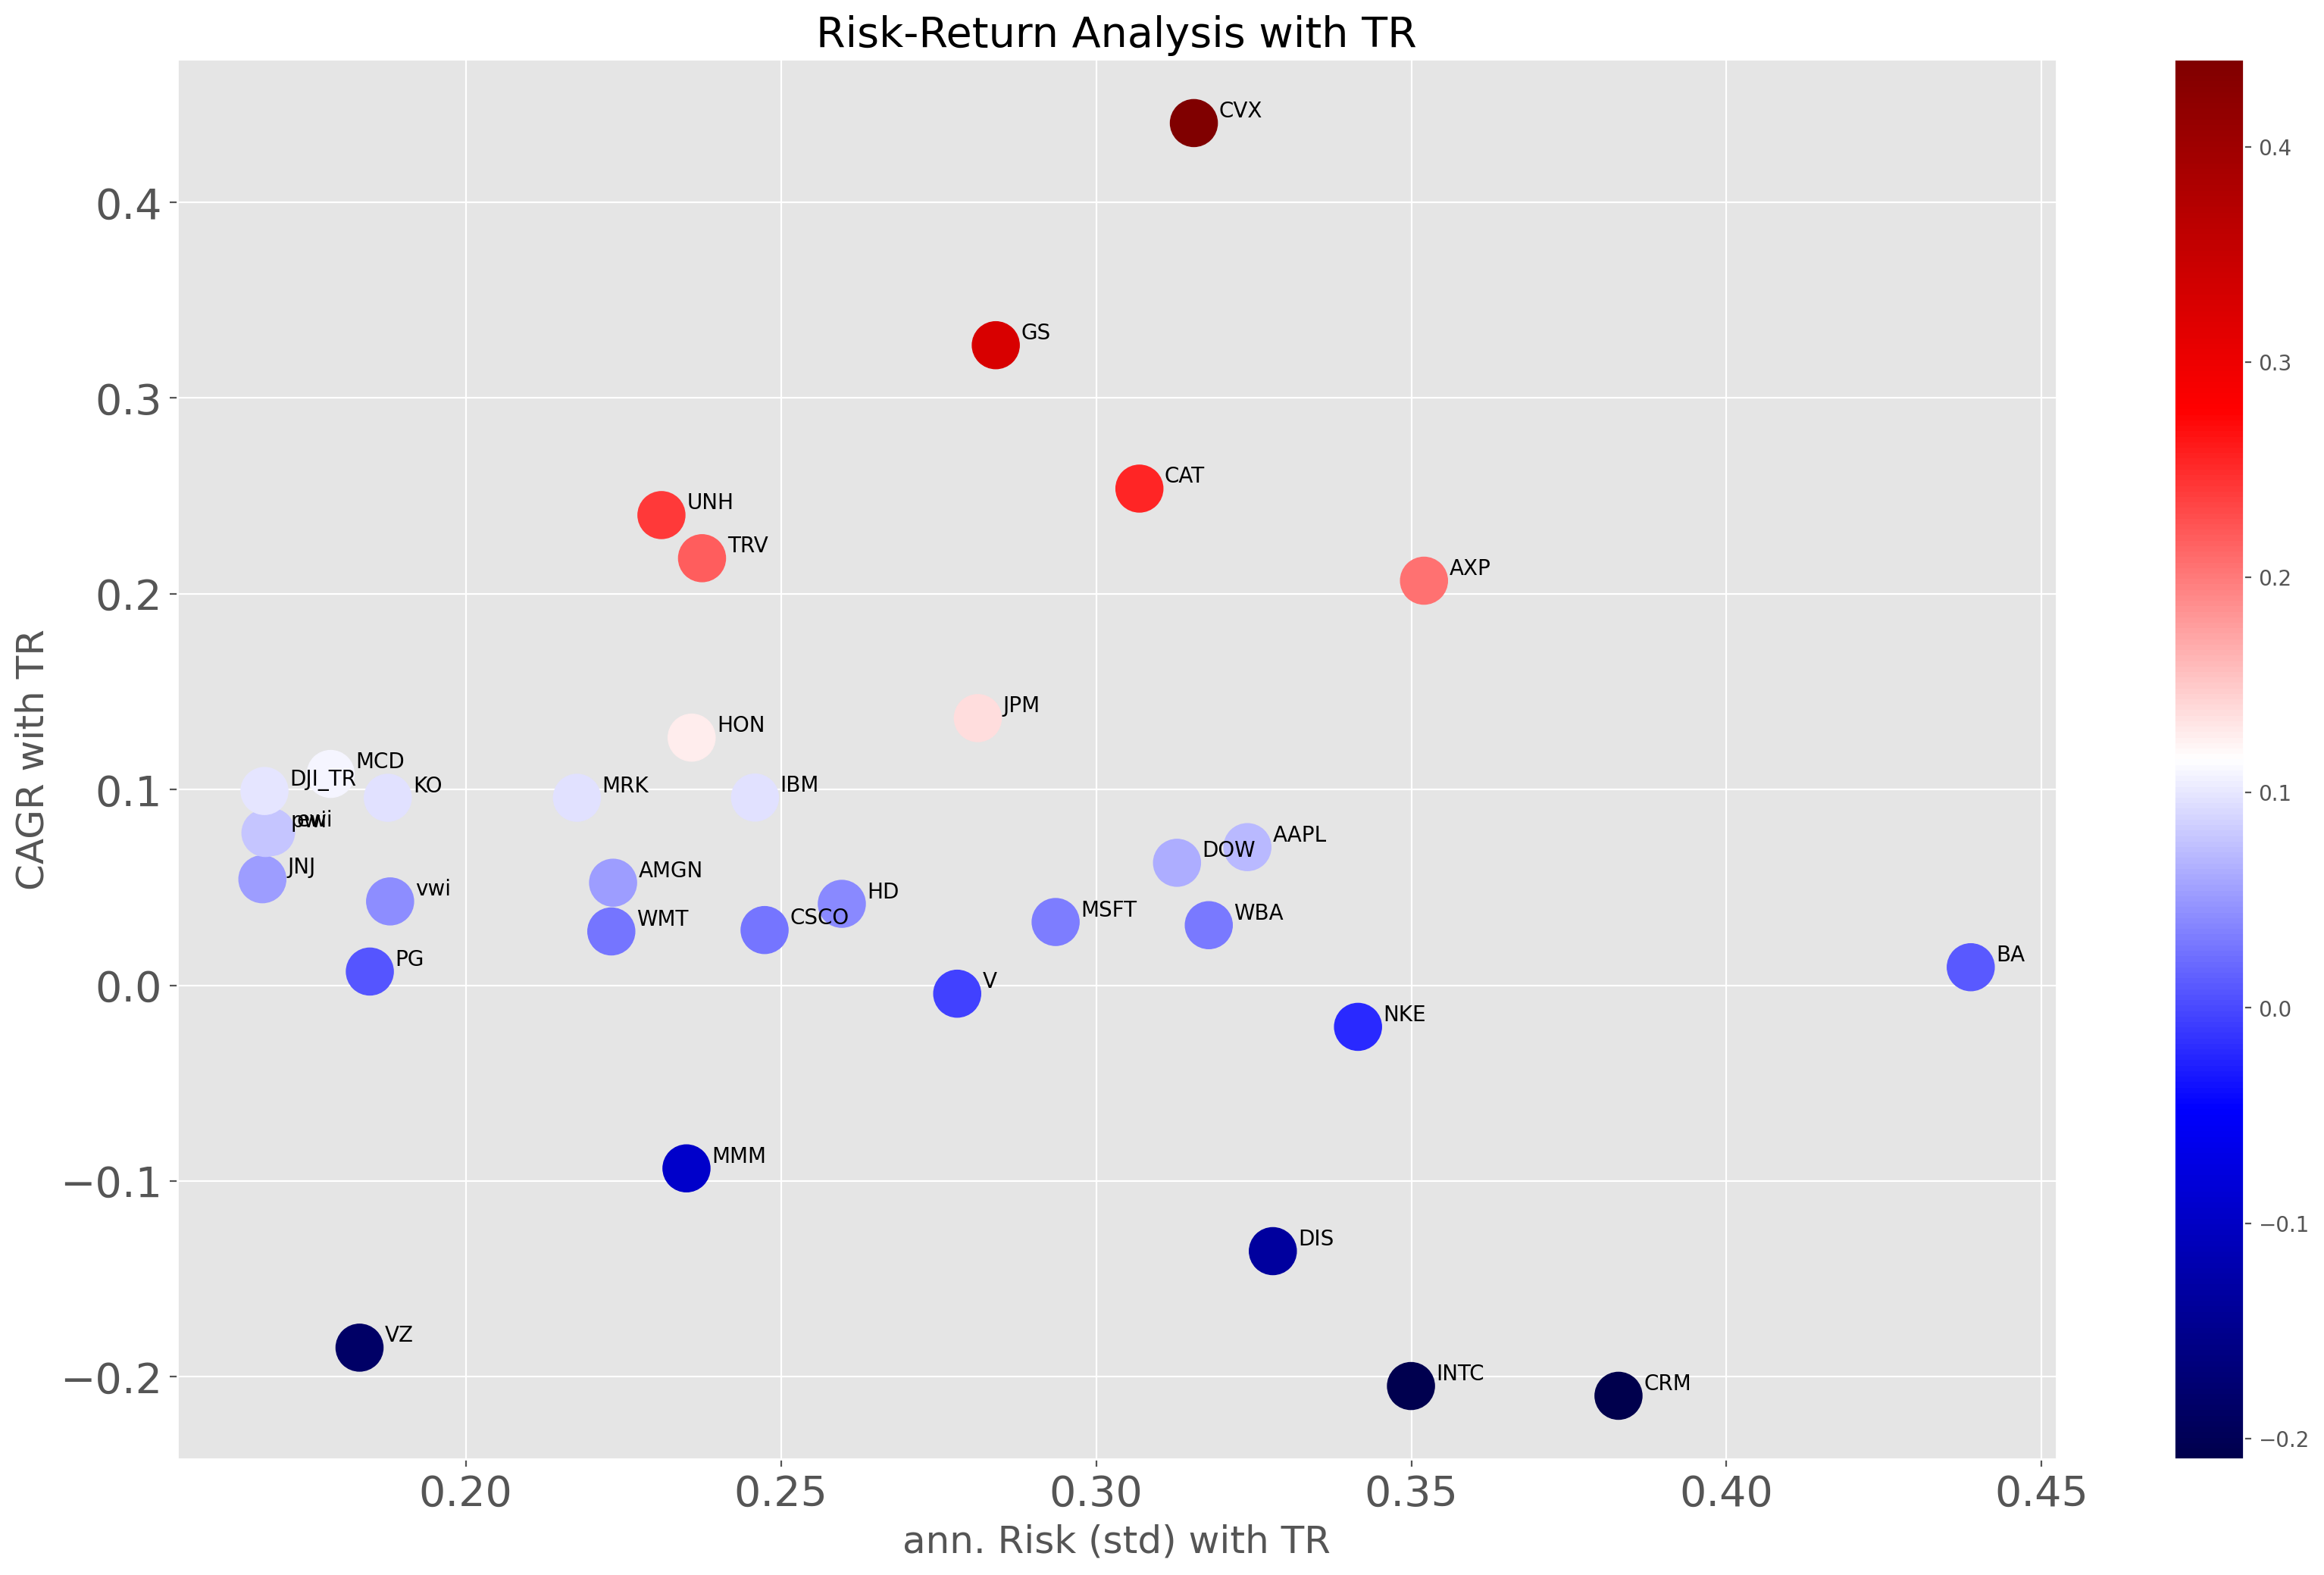

In [169]:
summary_TR.plot(kind = "scatter", 
             x = "ann. Risk", 
             y = "CAGR", 
             figsize = (20,12), 
             s = 500, 
             fontsize = 20 , 
             cmap = "seismic", 
             c = summary_TR["CAGR"])
for i in summary.index:
    plt.annotate(i, 
                 xy=(summary_TR.loc[i, "ann. Risk"]+0.004, summary_TR.loc[i, "CAGR"]+0.003), 
                 size = 10)
plt.xlabel("ann. Risk (std) with TR", fontsize = 18)
plt.ylabel("CAGR with TR", fontsize = 18)
plt.title("Risk-Return Analysis with TR", fontsize = 20)

plt.show()

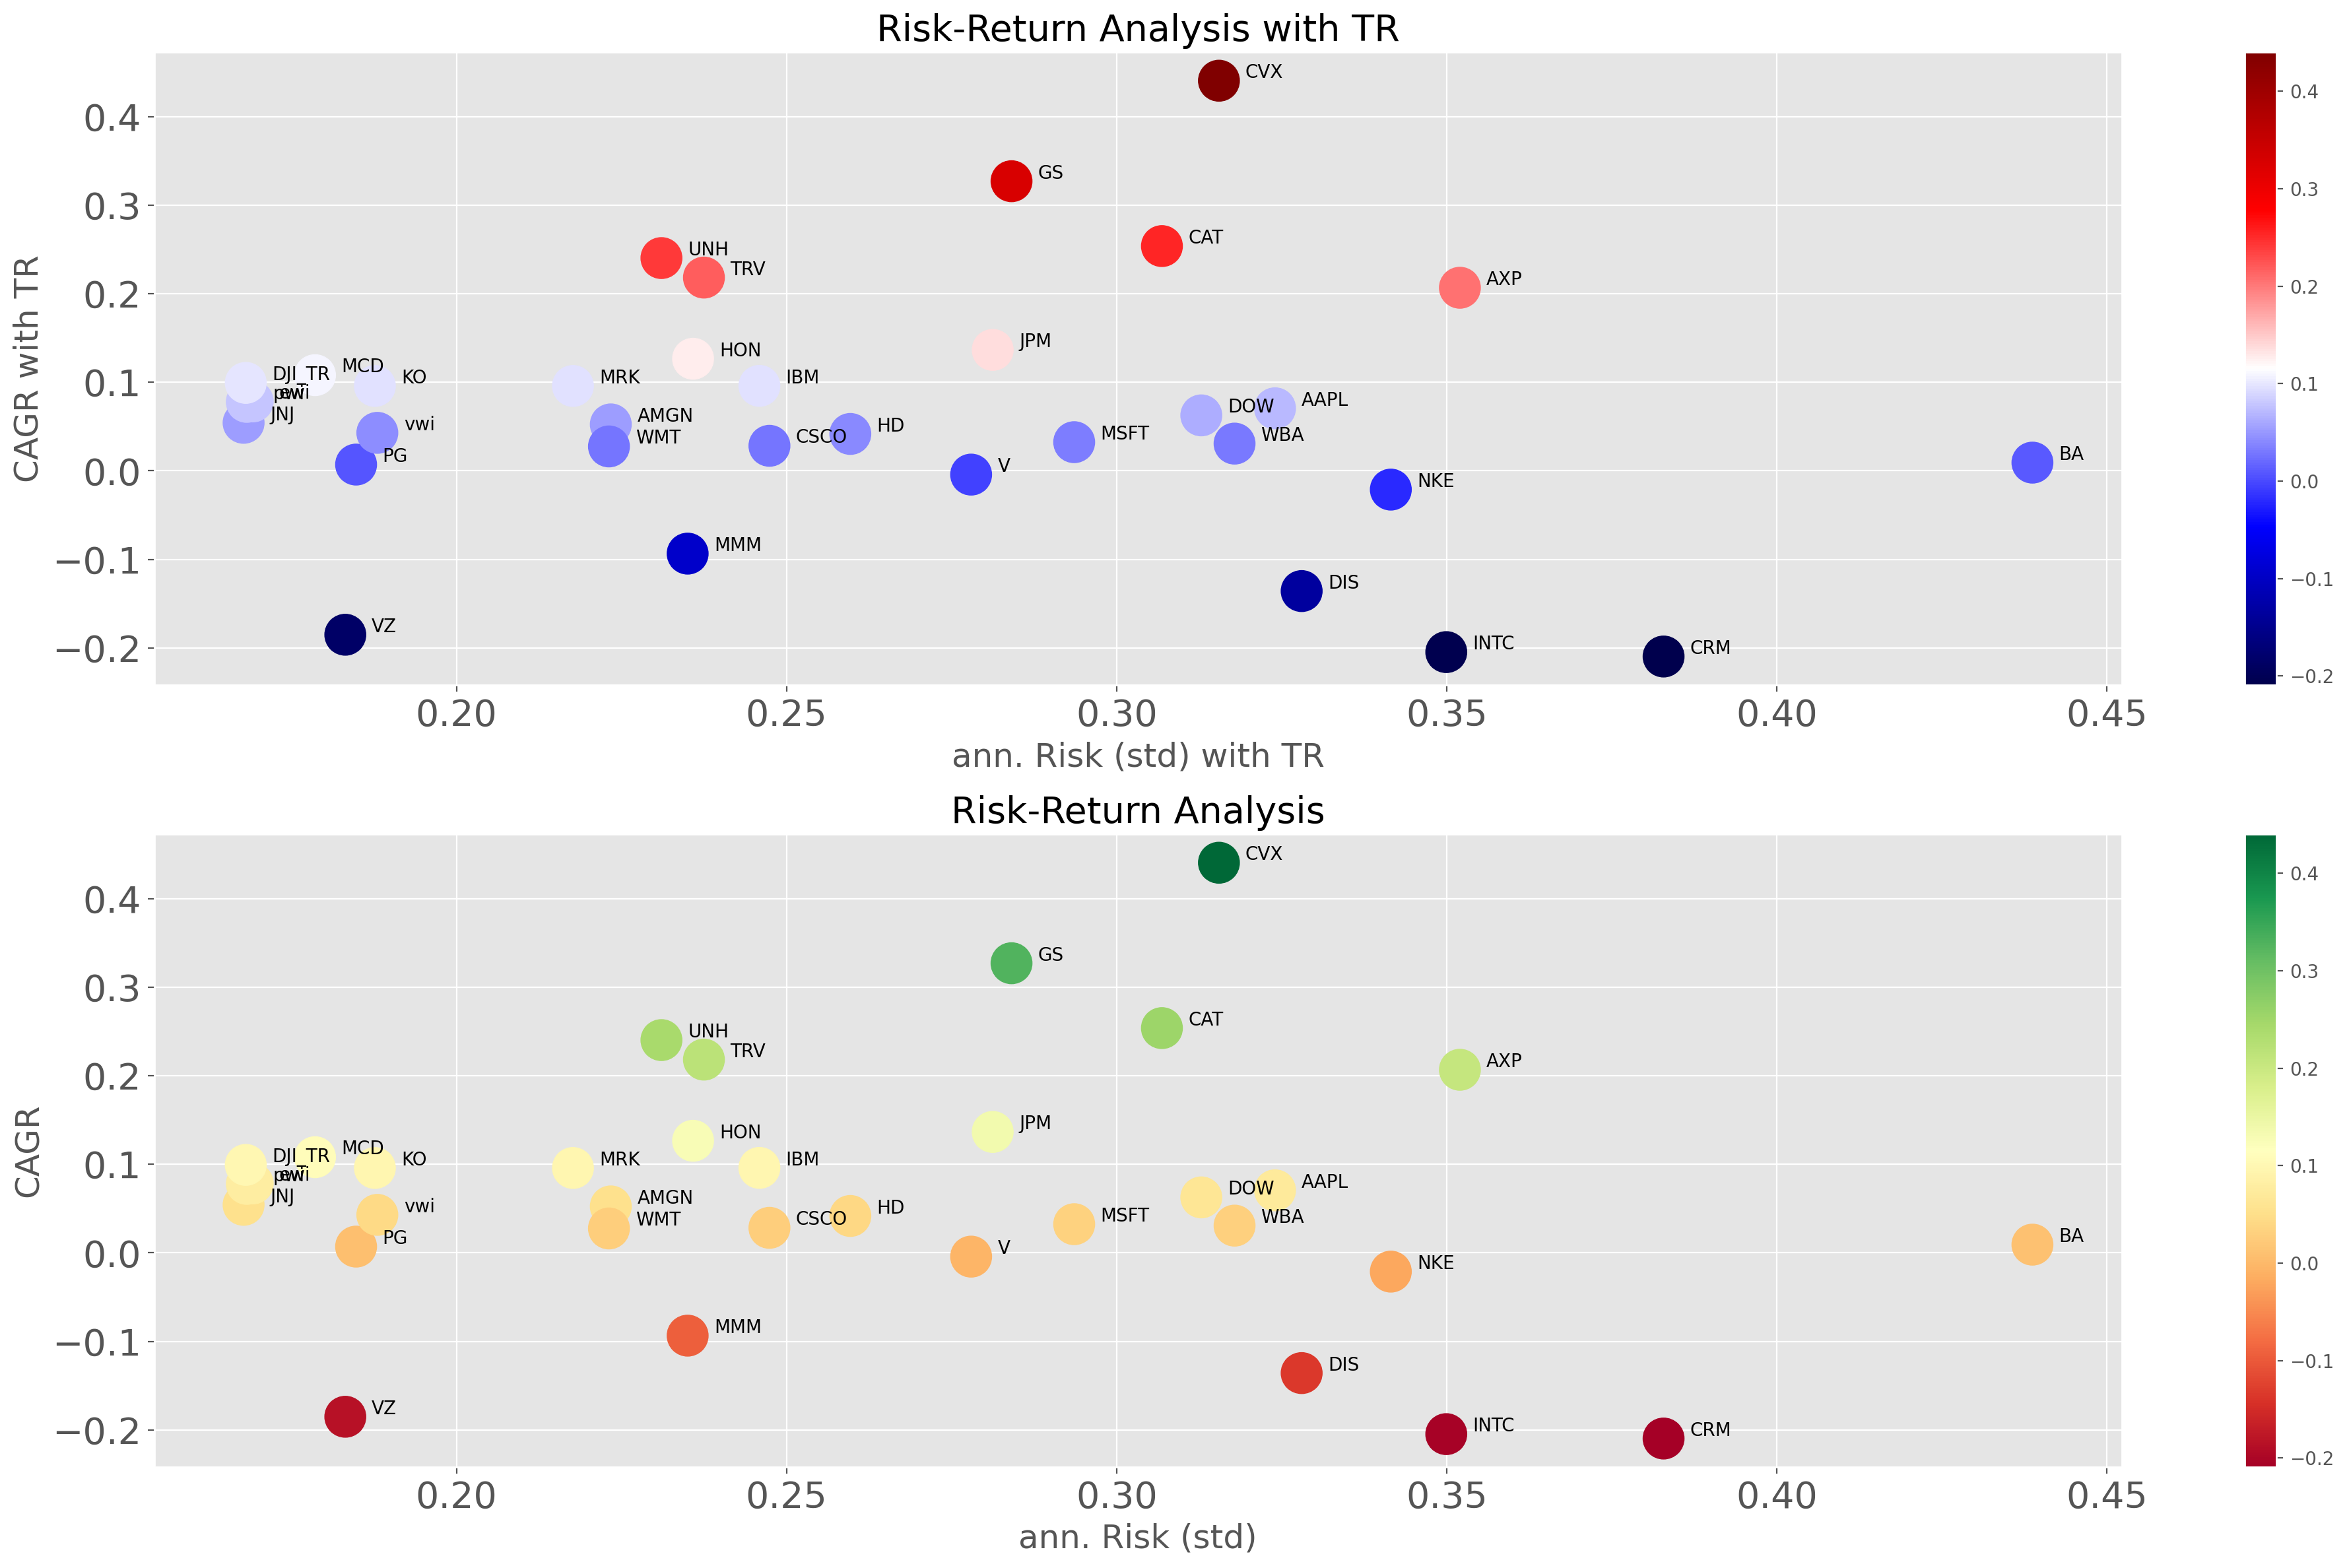

In [176]:
fig , ax = plt.subplots(figsize = (16,9), nrows = 2 , ncols = 1)

summary_TR.plot(kind = "scatter", 
             x = "ann. Risk", 
             y = "CAGR", 
             figsize = (20,12), 
             s = 500, 
             fontsize = 20 , 
             cmap = "seismic", 
             c = summary_TR["CAGR"],
             ax = ax[0])
for i in summary.index:
    ax[0].annotate(i, 
                 xy=(summary_TR.loc[i, "ann. Risk"]+0.004, summary_TR.loc[i, "CAGR"]+0.003), 
                 size = 10)
ax[0].set_xlabel("ann. Risk (std) with TR", fontsize = 18)
ax[0].set_ylabel("CAGR with TR", fontsize = 18)
ax[0].set_title("Risk-Return Analysis with TR", fontsize = 20)


summary.plot(kind = "scatter", 
             x = "ann. Risk", 
             y = "CAGR", 
             figsize = (20,12), 
             s = 500, 
             fontsize = 20 , 
             cmap = "RdYlGn" , 
             c = summary["CAGR"],
             ax = ax[1])
for i in summary.index:
    ax[1].annotate(i, 
                 xy=(summary.loc[i, "ann. Risk"]+0.004, summary.loc[i, "CAGR"]+0.003), 
                 size = 10)
ax[1].set_xlabel("ann. Risk (std)", fontsize = 18)
ax[1].set_ylabel("CAGR", fontsize = 18)
ax[1].set_title("Risk-Return Analysis", fontsize = 20)


plt.tight_layout()
plt.show()

